In [2]:
import pandas as pd
from glob import glob
import os

base_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/train/train'

all_files = []

for user_folder in glob(os.path.join(base_path, '*')):

    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):

        df = pd.read_csv(csv_file)

        df["user"] = user
        df["source_file"] = os.path.basename(csv_file)

        all_files.append(df)

train_rows = pd.concat(all_files, ignore_index=True)

print(train_rows.shape)
train_rows.head()

(3306000, 11)


,index,mean_x,mean_y,mean_z,std_x,std_y,std_z,label,file_id,user,source_file
0,0,-0.749747,0.356915,0.545894,0.006219,0.007540,0.002712,0,4474,User_024,04474.csv
1,1,-0.748485,0.358635,0.546211,0.004960,0.007840,0.003465,0,4474,User_024,04474.csv
2,2,-0.748642,0.359260,0.546369,0.005152,0.007853,0.003776,0,4474,User_024,04474.csv
3,3,-0.748958,0.356915,0.545894,0.005501,0.007540,0.002712,0,4474,User_024,04474.csv
4,4,-0.750693,0.356447,0.545578,0.006865,0.007386,0.001582,0,4474,User_024,04474.csv


In [2]:
train_rows["user"].nunique()

60

In [3]:
train_rows["file_id"].nunique()

11020

In [4]:
file_labels = train_rows.groupby("file_id")["label"].first()

file_labels.value_counts(normalize=True).sort_index()

label
0    0.421325
1    0.426044
2    0.032486
3    0.059528
4    0.012886
5    0.047731
Name: proportion, dtype: float64

In [5]:
user_label_counts = pd.crosstab(
    train_rows["user"],
    train_rows["label"]
)

user_label_counts

label,0,1,2,3,4,5
user,,,,,,
User_001,27000,20100,900,5100,0,5700
User_002,19800,12600,1200,3000,0,9000
User_003,7200,36600,1500,1800,0,4200
User_004,21900,22200,3900,7800,900,5400
User_005,21000,37800,600,900,0,0
User_006,29400,19500,600,1200,0,3300
User_007,24300,18300,2100,1800,0,1500
User_008,16500,27000,4500,3600,0,0
User_009,23400,24300,900,3600,0,3000


In [6]:
(user_label_counts == 0).sum()

label
0     0
1     0
2     8
3     1
4    41
5    25
dtype: int64

In [3]:
feature_cols = ["mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z"]

file_level_features = (
    train_rows
    .groupby("file_id")
    .agg(
        label=("label", "first"),
        mean_x=("mean_x", "mean"),
        mean_y=("mean_y", "mean"),
        mean_z=("mean_z", "mean"),
        std_x=("std_x", "mean"),
        std_y=("std_y", "mean"),
        std_z=("std_z", "mean"),
    )
    .reset_index()
)

label_feature_means = (
    file_level_features
    .groupby("label")[["mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z"]]
    .mean()
)

label_feature_means

,mean_x,mean_y,mean_z,std_x,std_y,std_z
label,,,,,,
0,0.000613,0.012246,0.180045,0.009107,0.007918,0.009057
1,-0.251946,0.037840,0.240420,0.057322,0.043956,0.053497
2,-0.242476,-0.032082,0.040914,0.101812,0.088883,0.095395
3,-0.249876,-0.166674,0.006959,0.180194,0.172322,0.155199
4,-0.021172,-0.207761,0.468195,0.299791,0.362833,0.269581
5,-0.301594,0.079468,0.206245,0.110648,0.088053,0.096979


In [5]:
from sklearn.preprocessing import StandardScaler

scaled = train_rows.copy()
scaled[feature_cols] = StandardScaler().fit_transform(scaled[feature_cols])

scaled_label_means = scaled.groupby("label")[feature_cols].mean()
scaled_label_means

,mean_x,mean_y,mean_z,std_x,std_y,std_z
label,,,,,,
0,0.234353,0.001748,-0.027574,-0.396457,-0.358382,-0.395103
1,-0.173517,0.056788,0.077376,0.055114,-0.001297,0.067066
2,-0.158223,-0.093578,-0.269428,0.471804,0.443860,0.502787
3,-0.170173,-0.383012,-0.328451,1.205919,1.270620,1.124739
4,0.199171,-0.471367,0.473319,2.326054,3.158297,2.314285
5,-0.253695,0.146306,0.017970,0.554561,0.435642,0.519268


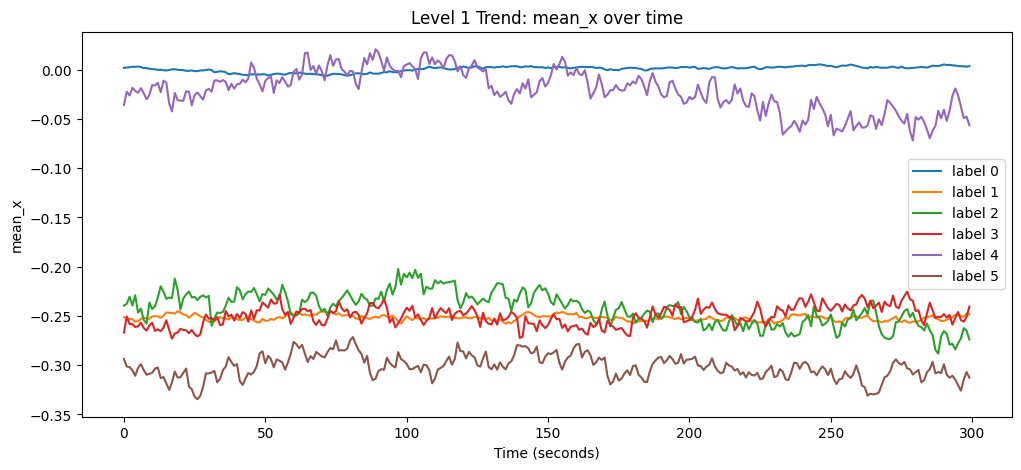

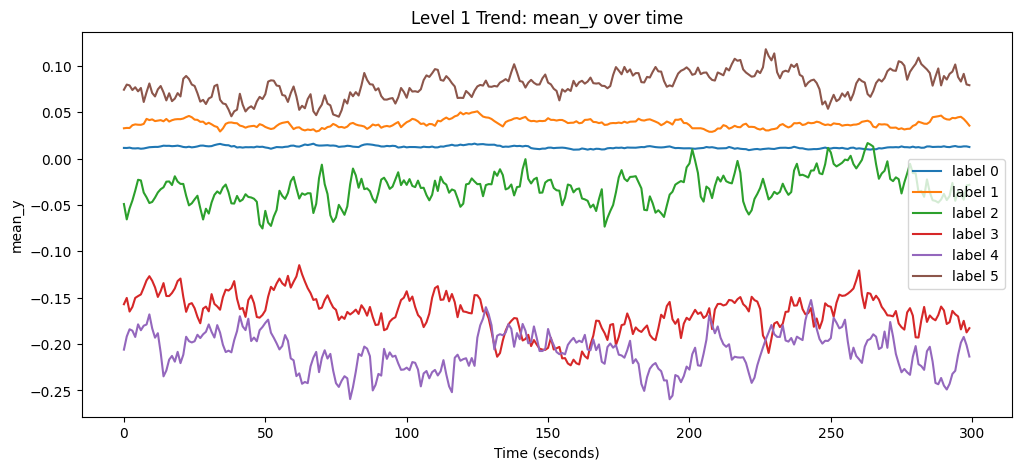

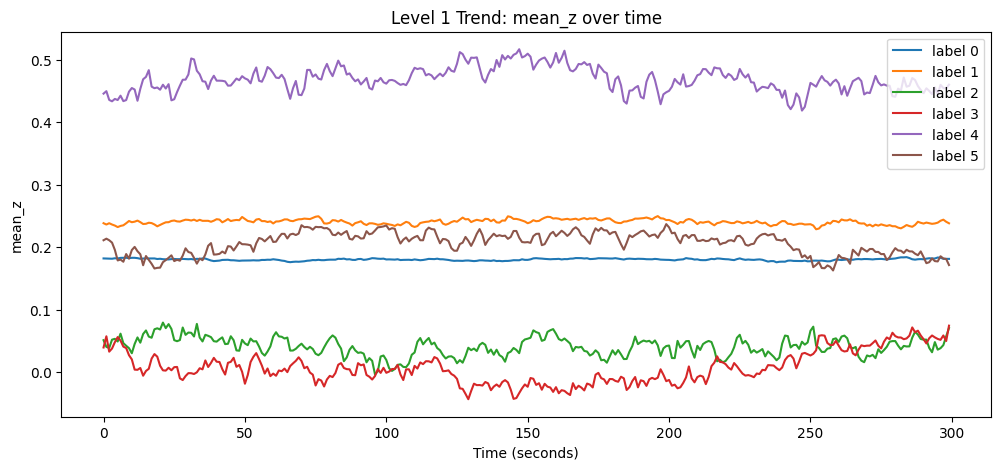

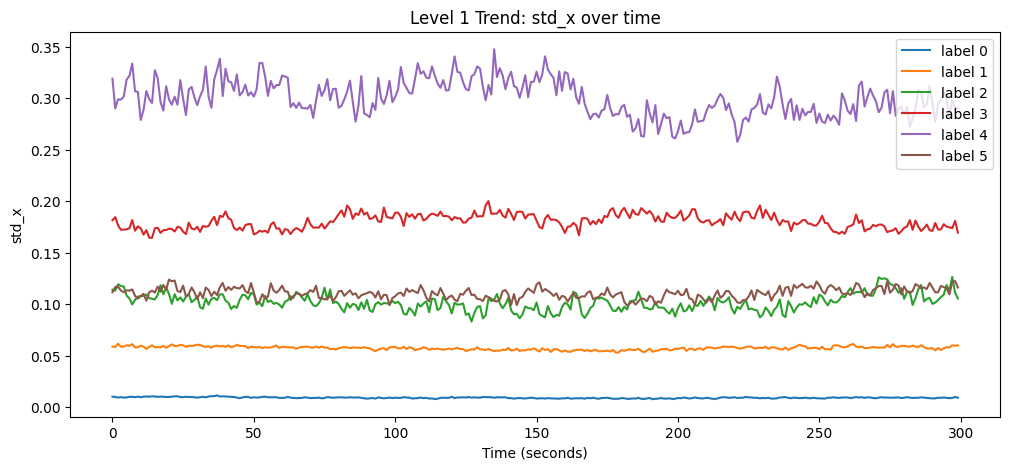

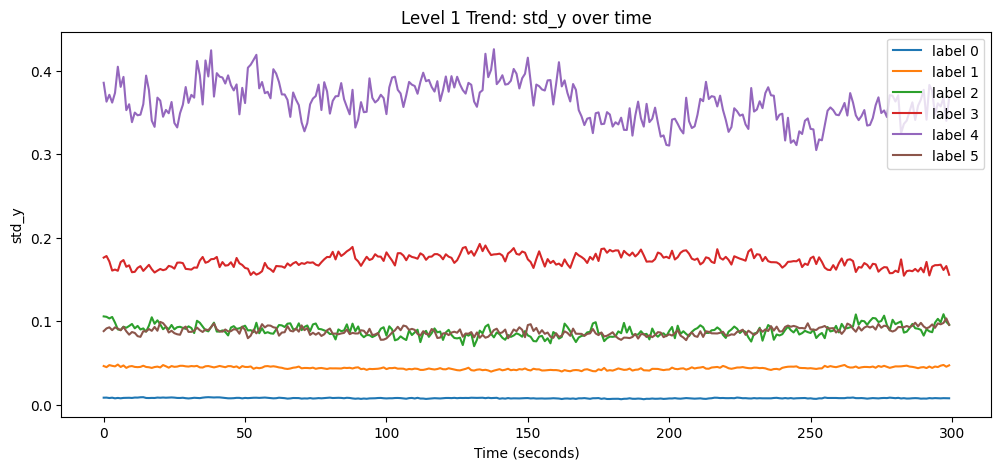

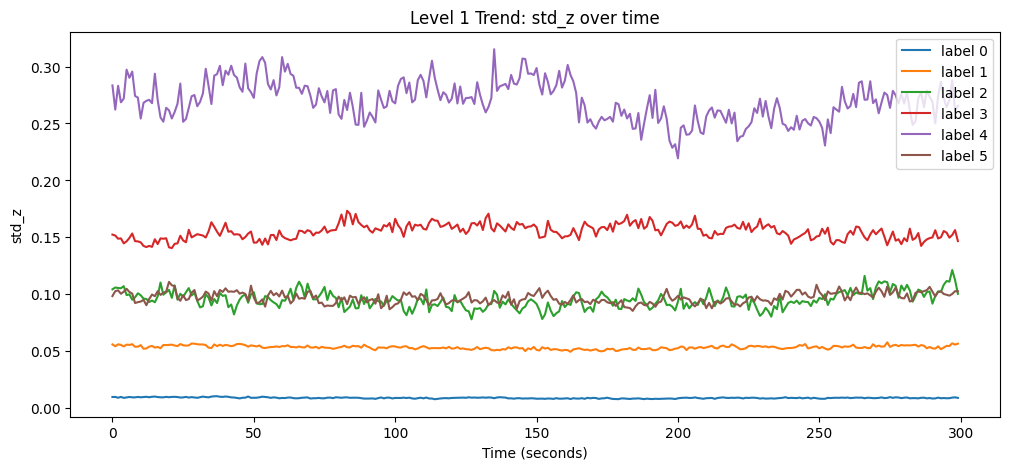

In [5]:
import matplotlib.pyplot as plt

label_trend = (
    train_rows
    .groupby(["label", "index"])[feature_cols]
    .mean()
    .reset_index()
)

labels = sorted(train_rows["label"].unique())

for feat in feature_cols:

    plt.figure(figsize=(12,5))

    for lbl in labels:
        subset = label_trend[label_trend["label"] == lbl]
        plt.plot(subset["index"], subset[feat], label=f"label {lbl}")

    plt.title(f"Level 1 Trend: {feat} over time")
    plt.xlabel("Time (seconds)")
    plt.ylabel(feat)
    plt.legend()
    plt.show()

/tmp/ipykernel_58/2980761412.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_slopes)


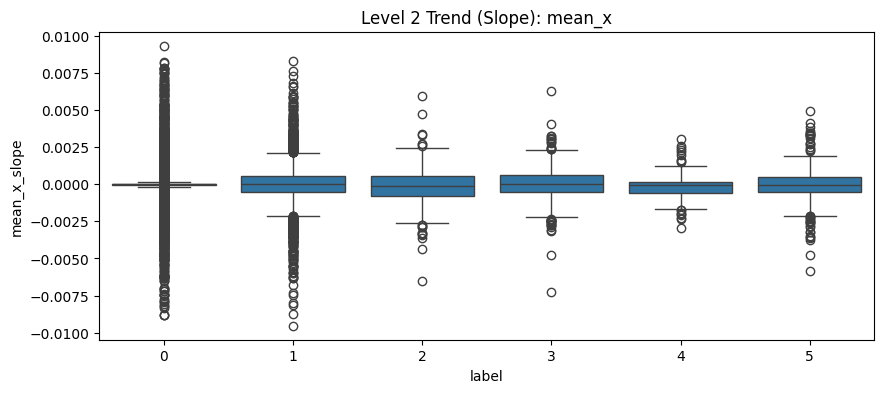

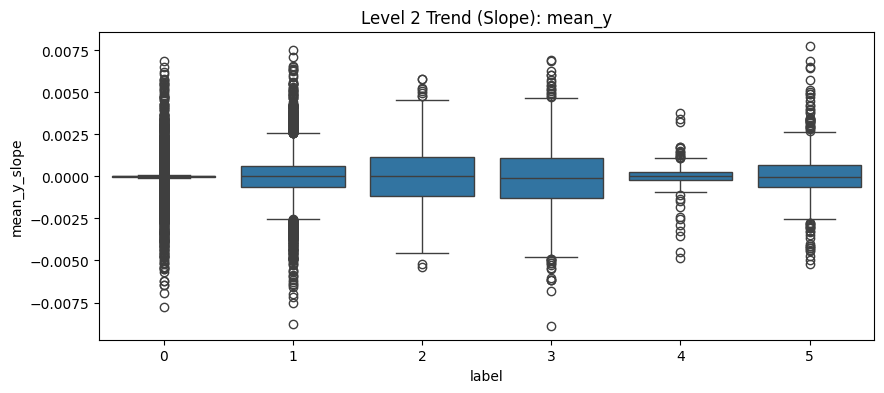

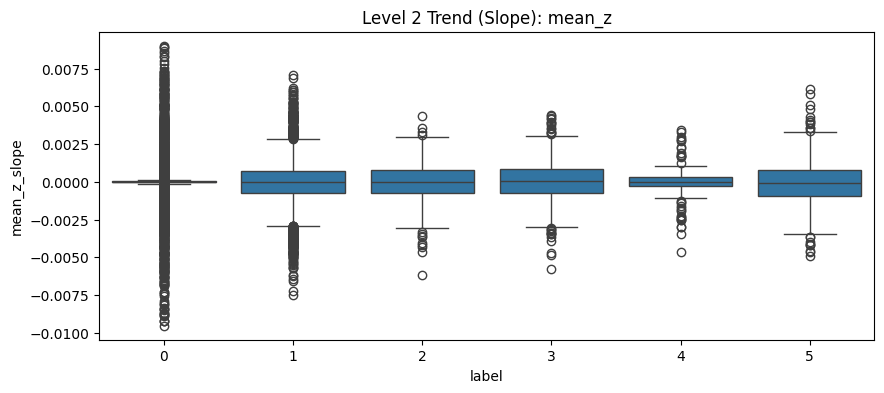

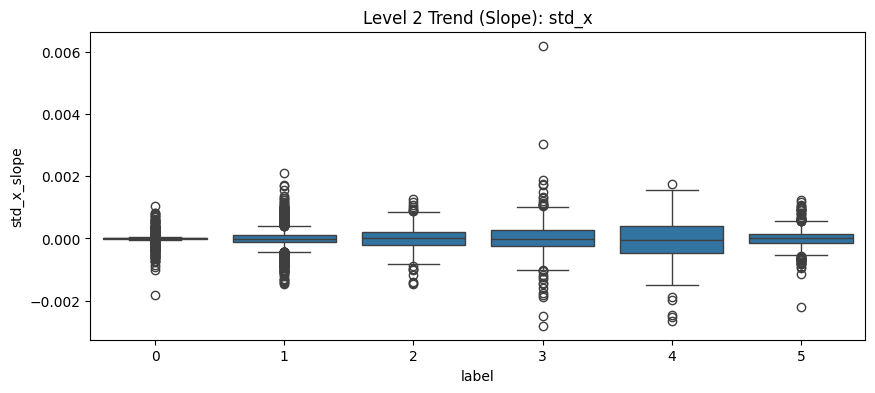

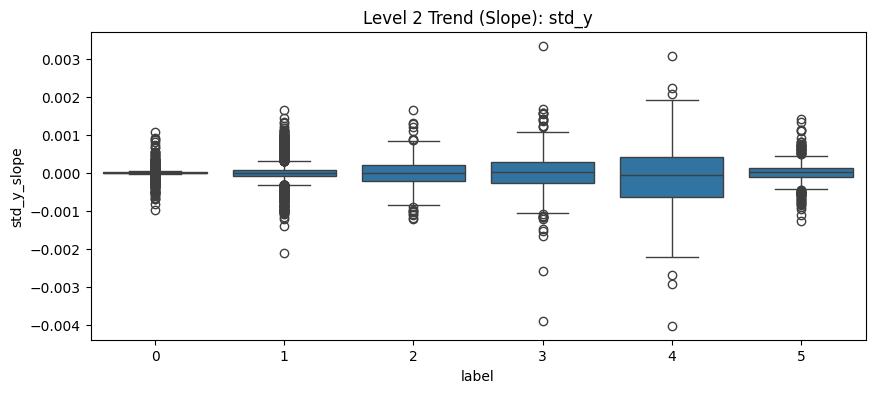

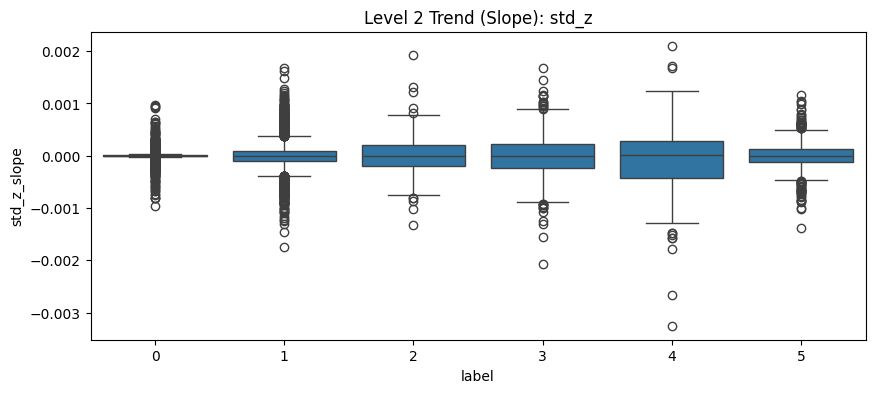

In [10]:
from scipy.stats import linregress

def compute_slopes(group):
    x = group["index"]

    result = {}
    for feat in feature_cols:
        result[f"{feat}_slope"] = linregress(x, group[feat]).slope

    return pd.Series(result)
    
slopes = (
    train_rows
    .groupby("file_id")
    .apply(compute_slopes)
    .reset_index()
)

slopes = slopes.merge(
    train_rows[["file_id", "label"]].drop_duplicates(),
    on="file_id"
)

slopes.groupby("label").mean()

import seaborn as sns

for feat in feature_cols:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        data=slopes,
        x="label",
        y=f"{feat}_slope"
    )

    plt.title(f"Level 2 Trend (Slope): {feat}")
    plt.show()

/tmp/ipykernel_58/929772858.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  norm = train_rows.groupby("file_id").apply(normalize_group).reset_index(drop=True)


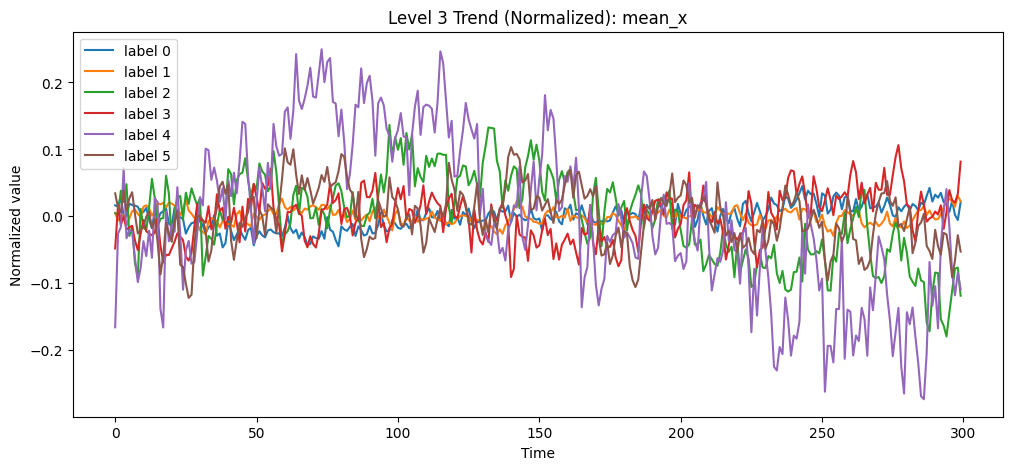

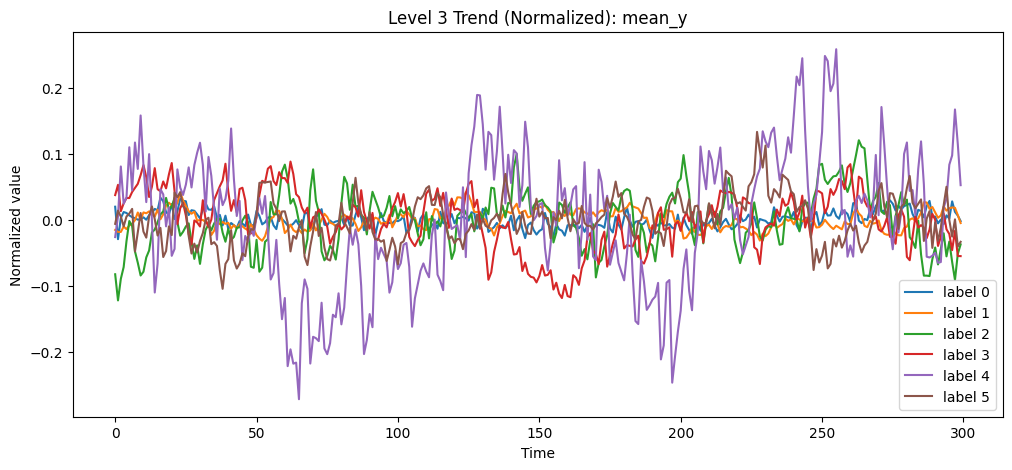

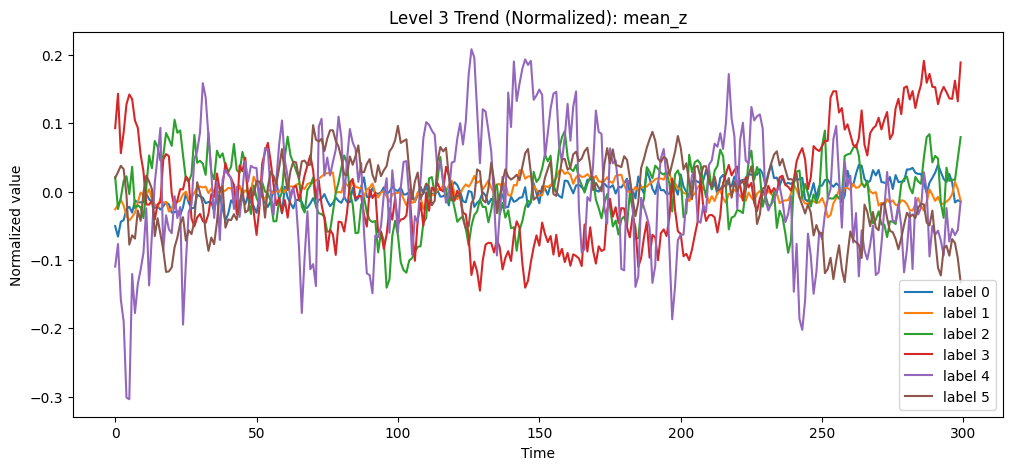

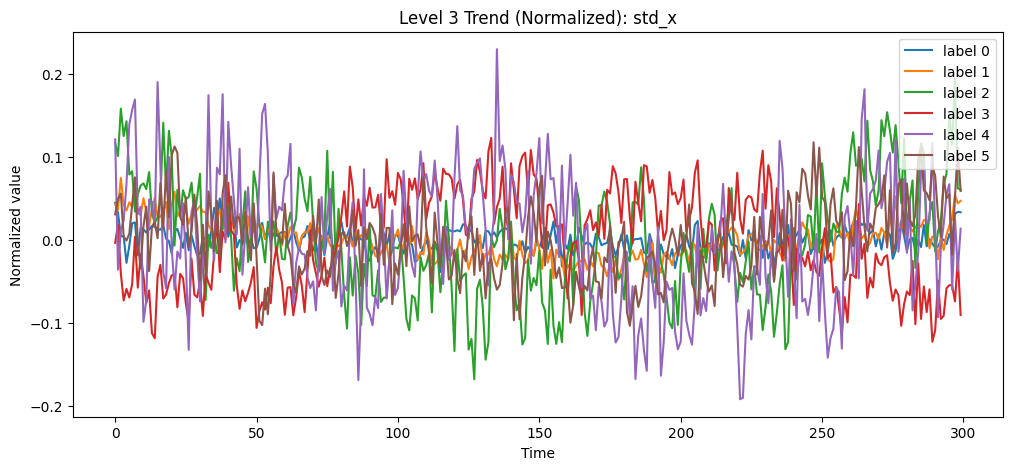

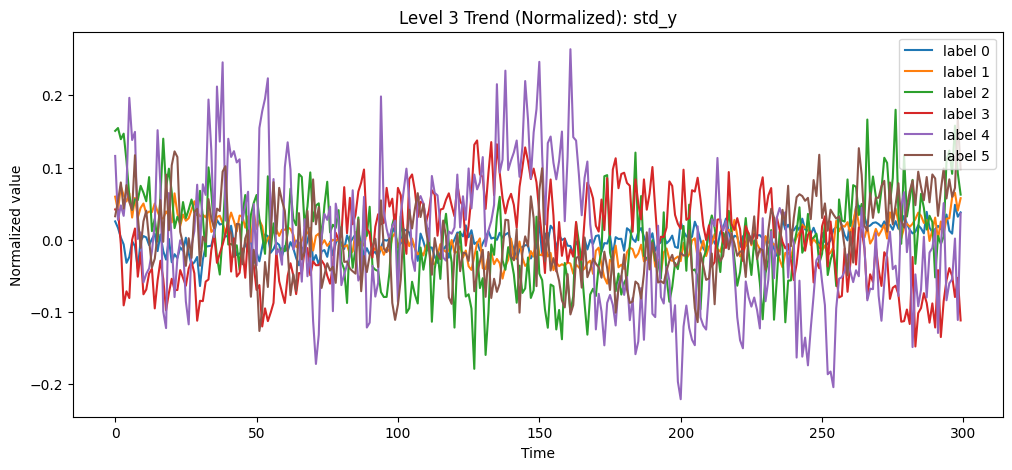

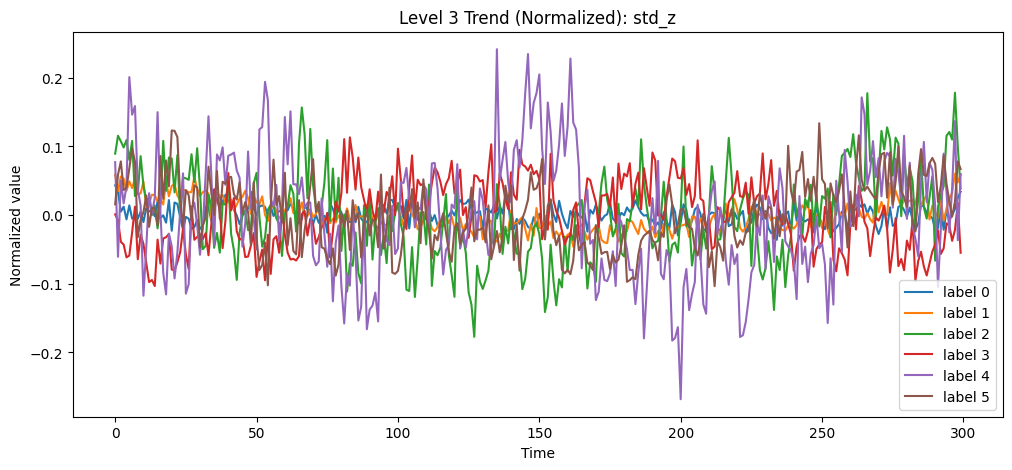

In [11]:
def normalize_group(g):
    g = g.copy()

    for feat in feature_cols:
        g[feat + "_norm"] = (
            g[feat] - g[feat].mean()
        ) / (g[feat].std() + 1e-8)

    return g

norm = train_rows.groupby("file_id").apply(normalize_group).reset_index(drop=True)

norm_trend = (
    norm
    .groupby(["label", "index"])[[f + "_norm" for f in feature_cols]]
    .mean()
    .reset_index()
)

labels = sorted(train_rows["label"].unique())

for feat in feature_cols:

    plt.figure(figsize=(12,5))

    for lbl in labels:
        subset = norm_trend[norm_trend["label"] == lbl]
        plt.plot(subset["index"], subset[feat + "_norm"], label=f"label {lbl}")

    plt.title(f"Level 3 Trend (Normalized): {feat}")
    plt.xlabel("Time")
    plt.ylabel("Normalized value")
    plt.legend()
    plt.show()


Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6540


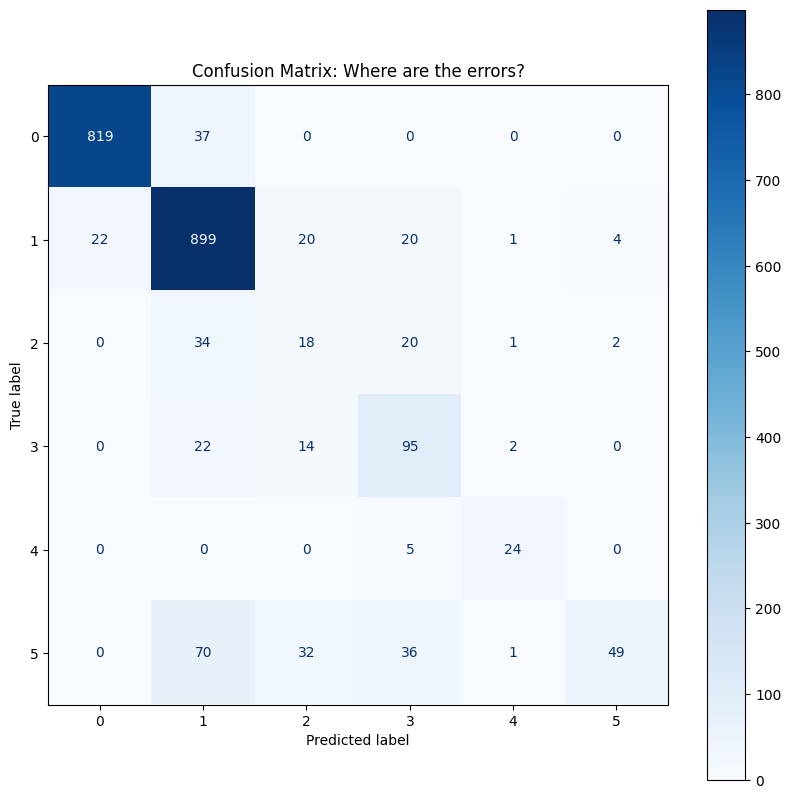


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9652 (Support: 856.0)
Label 1: F1 = 0.8866 (Support: 966.0)
Label 2: F1 = 0.2264 (Support: 75.0)
Label 3: F1 = 0.6149 (Support: 133.0)
Label 4: F1 = 0.8276 (Support: 29.0)
Label 5: F1 = 0.4033 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.7037


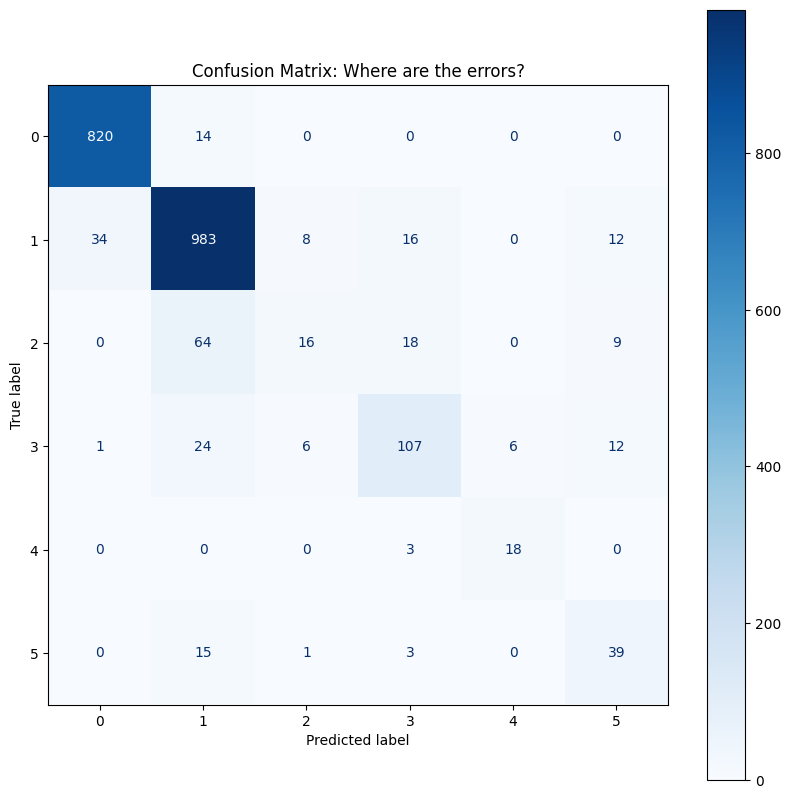


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9710 (Support: 834.0)
Label 1: F1 = 0.9131 (Support: 1053.0)
Label 2: F1 = 0.2319 (Support: 107.0)
Label 3: F1 = 0.7063 (Support: 156.0)
Label 4: F1 = 0.8000 (Support: 21.0)
Label 5: F1 = 0.6000 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7567


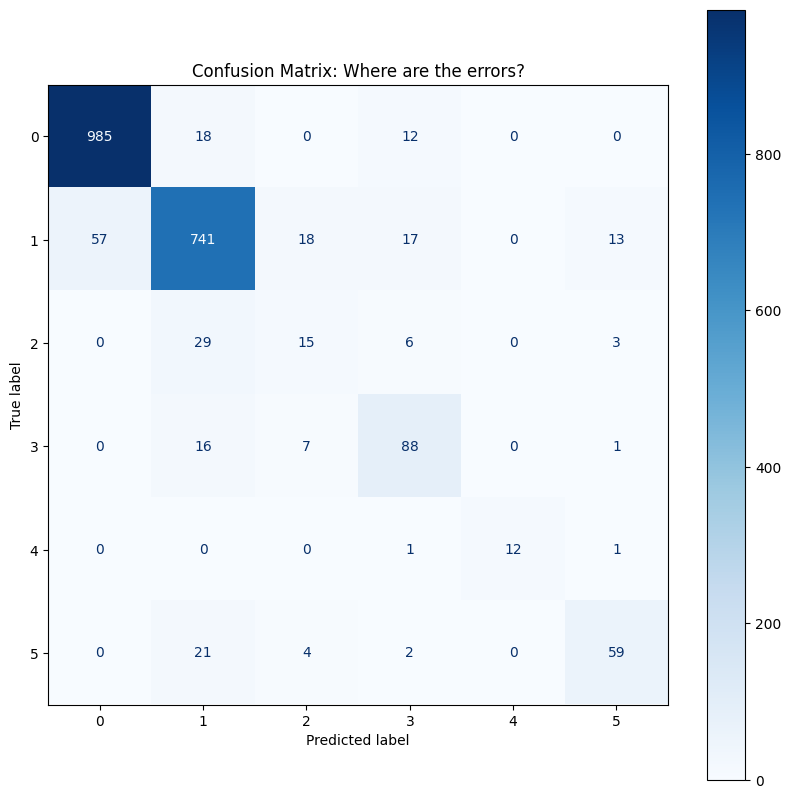


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9577 (Support: 1015.0)
Label 1: F1 = 0.8869 (Support: 846.0)
Label 2: F1 = 0.3093 (Support: 53.0)
Label 3: F1 = 0.7395 (Support: 112.0)
Label 4: F1 = 0.9231 (Support: 14.0)
Label 5: F1 = 0.7239 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7354


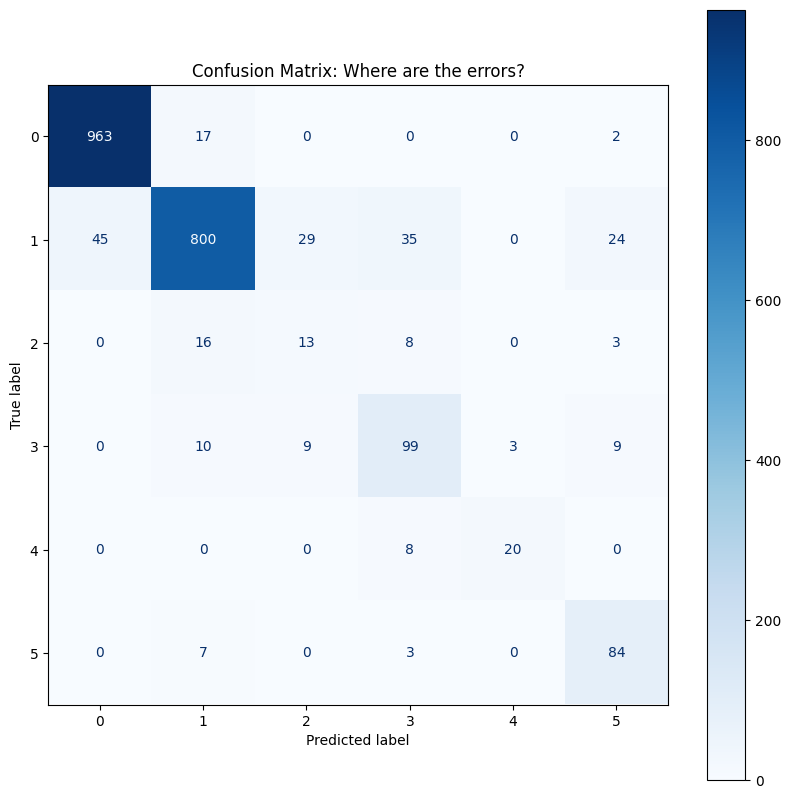


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9678 (Support: 982.0)
Label 1: F1 = 0.8974 (Support: 933.0)
Label 2: F1 = 0.2857 (Support: 40.0)
Label 3: F1 = 0.6996 (Support: 130.0)
Label 4: F1 = 0.7843 (Support: 28.0)
Label 5: F1 = 0.7778 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.6711


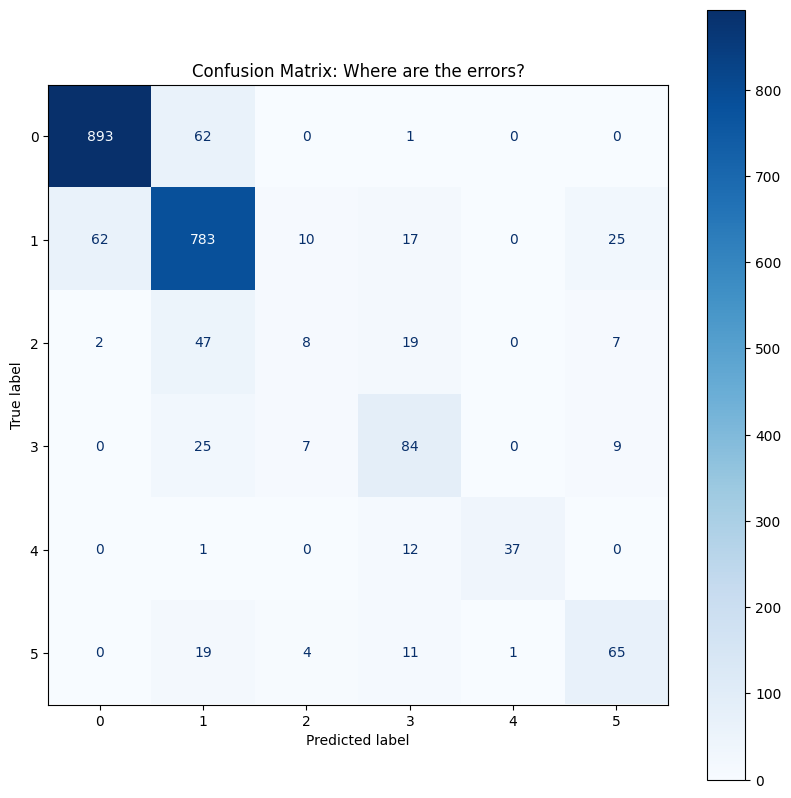


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9336 (Support: 956.0)
Label 1: F1 = 0.8539 (Support: 897.0)
Label 2: F1 = 0.1429 (Support: 83.0)
Label 3: F1 = 0.6245 (Support: 125.0)
Label 4: F1 = 0.8409 (Support: 50.0)
Label 5: F1 = 0.6311 (Support: 100.0)


In [12]:
# Initial baseline 1
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}
    
    for col in feature_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = np.gradient(df[col]).mean()

    mag_mean = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    mag_std = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    feats["mag_mean_mean"] = mag_mean.mean()
    feats["mag_mean_std"] = mag_mean.std()
    feats["mag_std_mean"] = mag_std.mean()
    feats["mag_std_std"] = mag_std.std()
    
    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.7,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)

    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")

In [13]:
test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):

    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):

        df = pd.read_csv(csv_file)

        df["source_file"] = os.path.basename(csv_file)

        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

print(test_rows.shape)
test_rows.head()

print("Training Final Model on 100% of Data...")
lgbm_model.fit(X, y)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)

X_test = test_df.drop(columns=["file_id"])

print("Predicting Test Probabilities...")
test_raw_probs = lgbm_model.predict_proba(X_test)

test_preds = np.argmax(test_raw_probs, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")

(2054700, 9)
Training Final Model on 100% of Data...
Predicting Test Probabilities...
submission.csv successfully generated.



Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6566


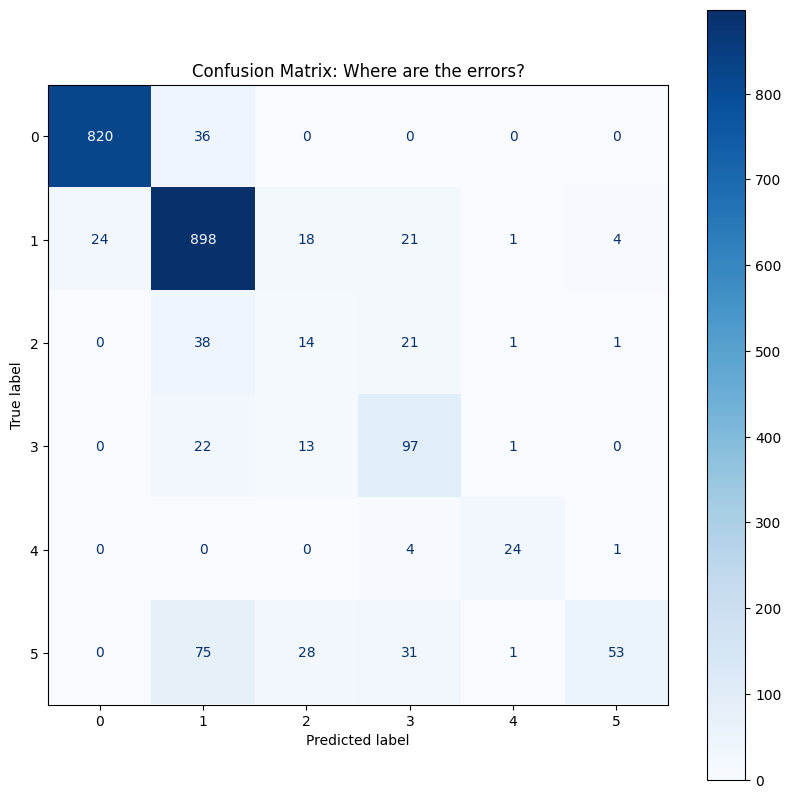


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9647 (Support: 856.0)
Label 1: F1 = 0.8826 (Support: 966.0)
Label 2: F1 = 0.1892 (Support: 75.0)
Label 3: F1 = 0.6319 (Support: 133.0)
Label 4: F1 = 0.8421 (Support: 29.0)
Label 5: F1 = 0.4291 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.6929


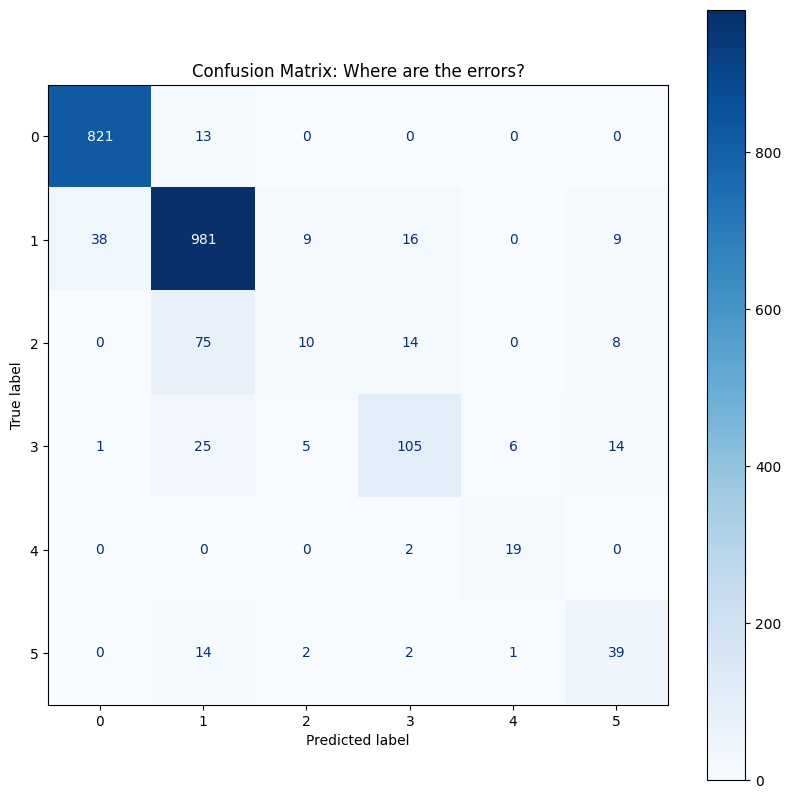


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9693 (Support: 834.0)
Label 1: F1 = 0.9079 (Support: 1053.0)
Label 2: F1 = 0.1504 (Support: 107.0)
Label 3: F1 = 0.7119 (Support: 156.0)
Label 4: F1 = 0.8085 (Support: 21.0)
Label 5: F1 = 0.6094 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7627


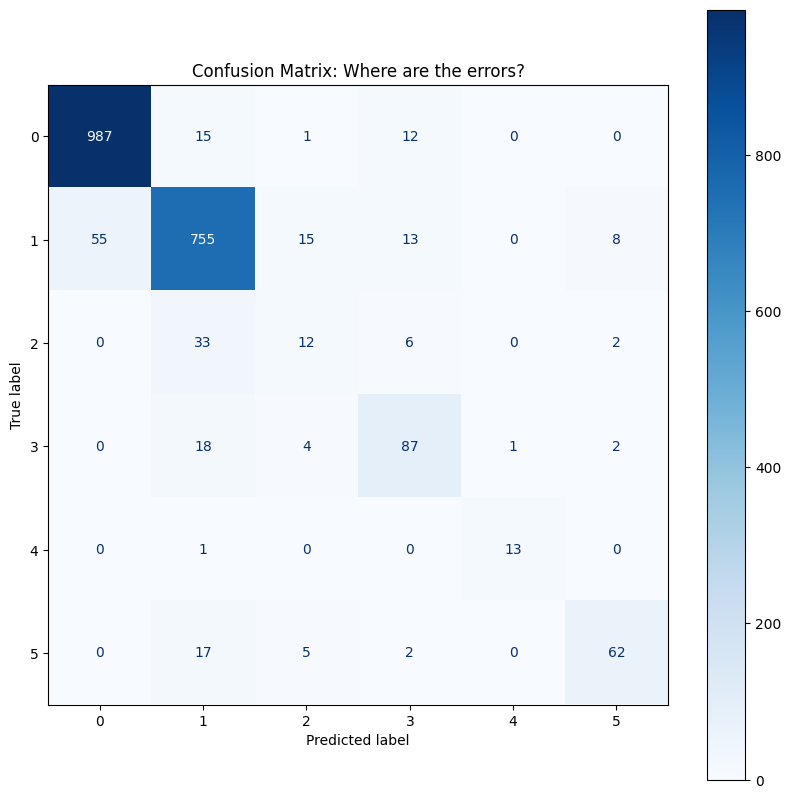


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9596 (Support: 1015.0)
Label 1: F1 = 0.8961 (Support: 846.0)
Label 2: F1 = 0.2667 (Support: 53.0)
Label 3: F1 = 0.7500 (Support: 112.0)
Label 4: F1 = 0.9286 (Support: 14.0)
Label 5: F1 = 0.7750 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7597


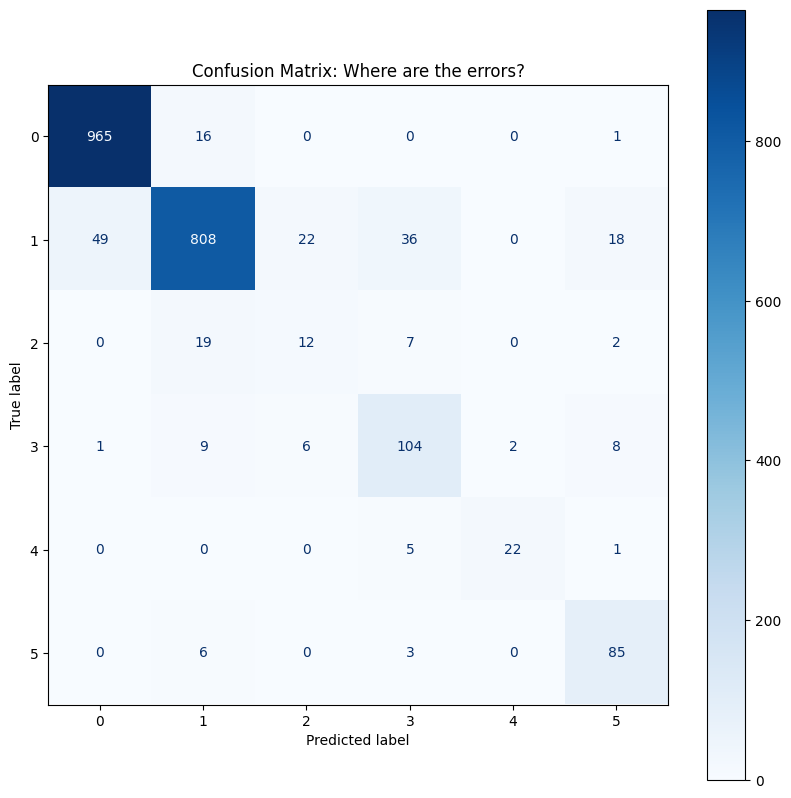


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9664 (Support: 982.0)
Label 1: F1 = 0.9023 (Support: 933.0)
Label 2: F1 = 0.3000 (Support: 40.0)
Label 3: F1 = 0.7298 (Support: 130.0)
Label 4: F1 = 0.8462 (Support: 28.0)
Label 5: F1 = 0.8134 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.6964


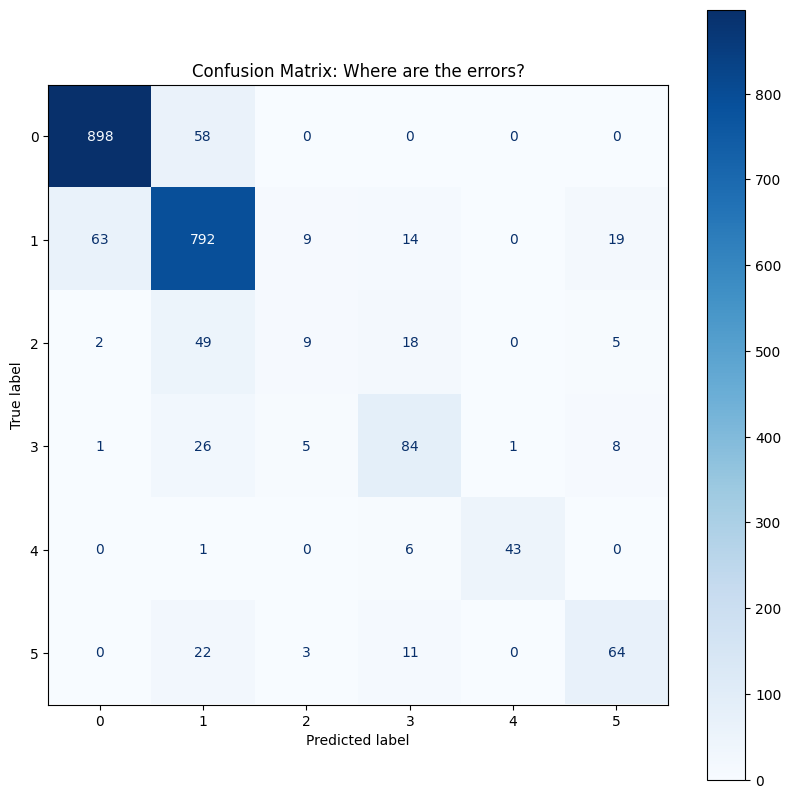


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9354 (Support: 956.0)
Label 1: F1 = 0.8585 (Support: 897.0)
Label 2: F1 = 0.1651 (Support: 83.0)
Label 3: F1 = 0.6512 (Support: 125.0)
Label 4: F1 = 0.9149 (Support: 50.0)
Label 5: F1 = 0.6531 (Support: 100.0)


In [26]:
# Adding angular changes and do the same extraction as the original feature and serve as baseline 2
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = df[col].diff().abs().mean()
    
    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.7,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)

    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")

In [27]:
test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):

    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):

        df = pd.read_csv(csv_file)

        df["source_file"] = os.path.basename(csv_file)

        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

print(test_rows.shape)
test_rows.head()

print("Training Final Model on 100% of Data...")
lgbm_model.fit(X, y)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

print("Predicting Test Probabilities...")
test_raw_probs = lgbm_model.predict_proba(X_test)
test_preds = np.argmax(test_raw_probs, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")

(2054700, 9)
Training Final Model on 100% of Data...
Predicting Test Probabilities...
submission.csv successfully generated.



Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6584


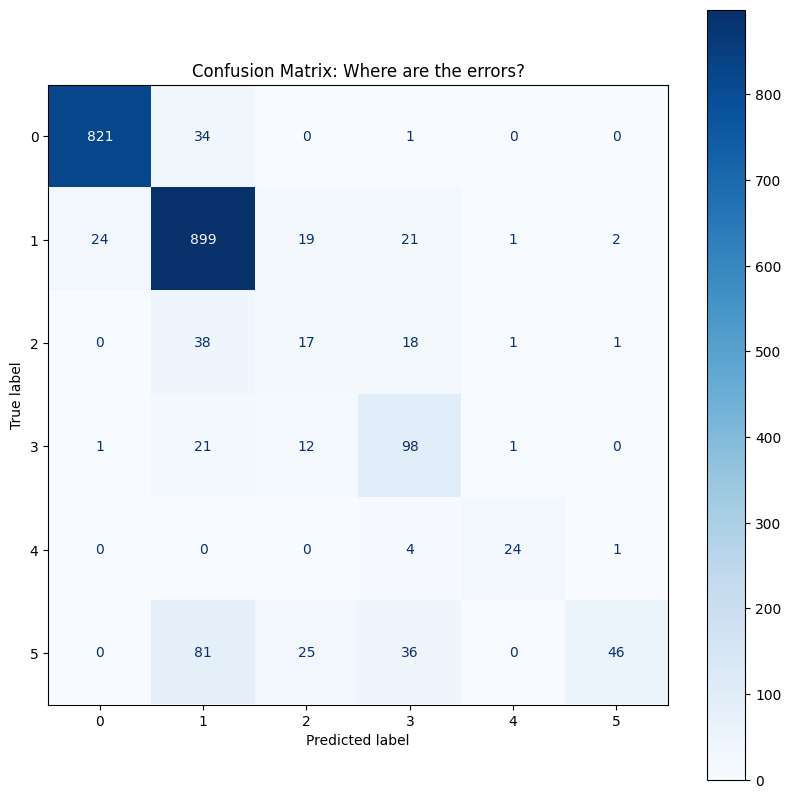


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9647 (Support: 856.0)
Label 1: F1 = 0.8818 (Support: 966.0)
Label 2: F1 = 0.2297 (Support: 75.0)
Label 3: F1 = 0.6302 (Support: 133.0)
Label 4: F1 = 0.8571 (Support: 29.0)
Label 5: F1 = 0.3866 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.6984


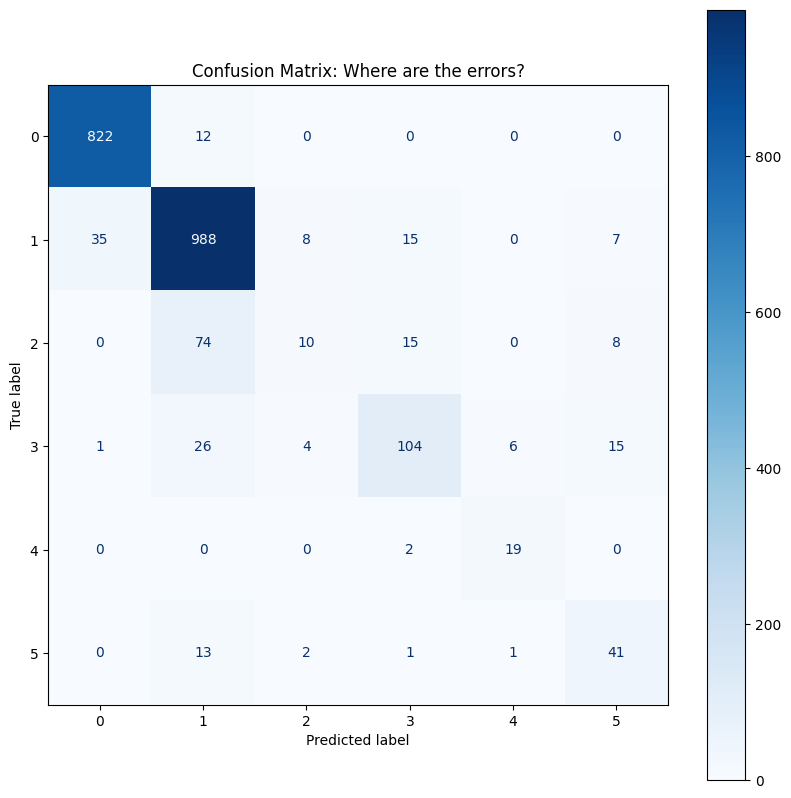


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9716 (Support: 834.0)
Label 1: F1 = 0.9123 (Support: 1053.0)
Label 2: F1 = 0.1527 (Support: 107.0)
Label 3: F1 = 0.7099 (Support: 156.0)
Label 4: F1 = 0.8085 (Support: 21.0)
Label 5: F1 = 0.6357 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7636


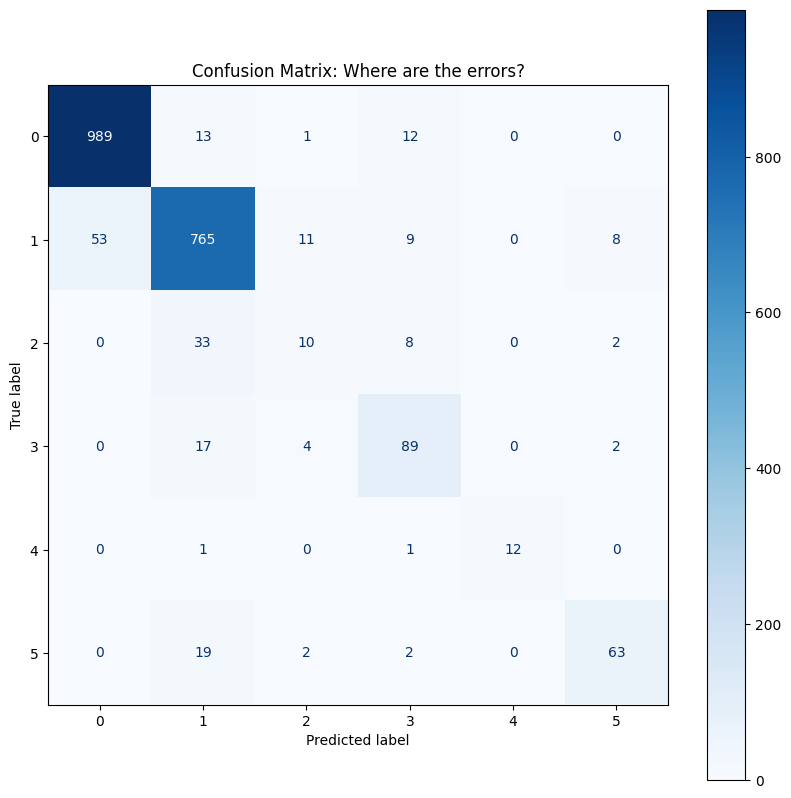


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9616 (Support: 1015.0)
Label 1: F1 = 0.9032 (Support: 846.0)
Label 2: F1 = 0.2469 (Support: 53.0)
Label 3: F1 = 0.7639 (Support: 112.0)
Label 4: F1 = 0.9231 (Support: 14.0)
Label 5: F1 = 0.7826 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7594


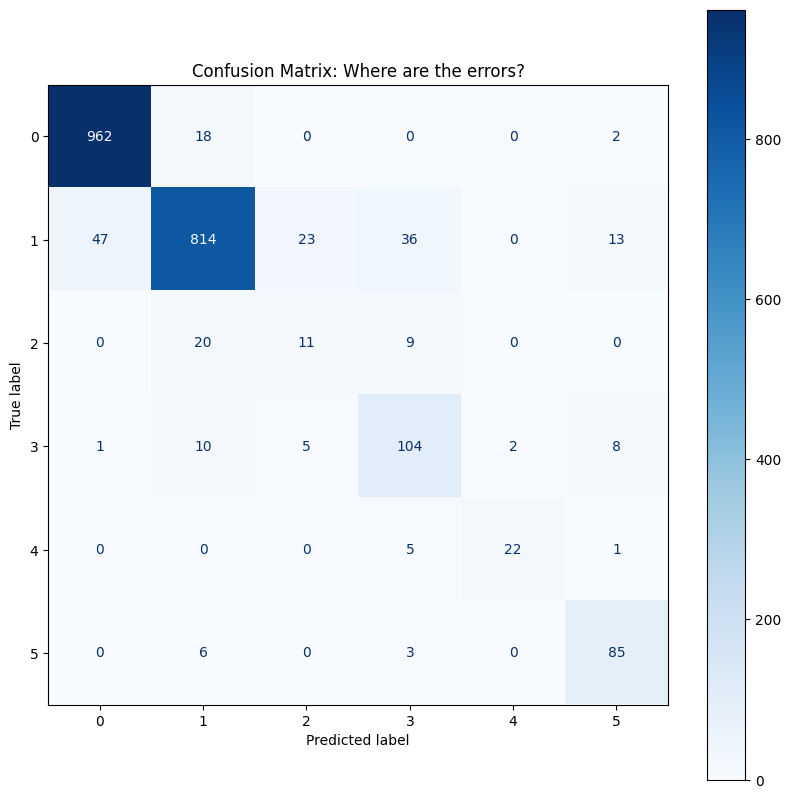


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9659 (Support: 982.0)
Label 1: F1 = 0.9039 (Support: 933.0)
Label 2: F1 = 0.2785 (Support: 40.0)
Label 3: F1 = 0.7247 (Support: 130.0)
Label 4: F1 = 0.8462 (Support: 28.0)
Label 5: F1 = 0.8374 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.6968


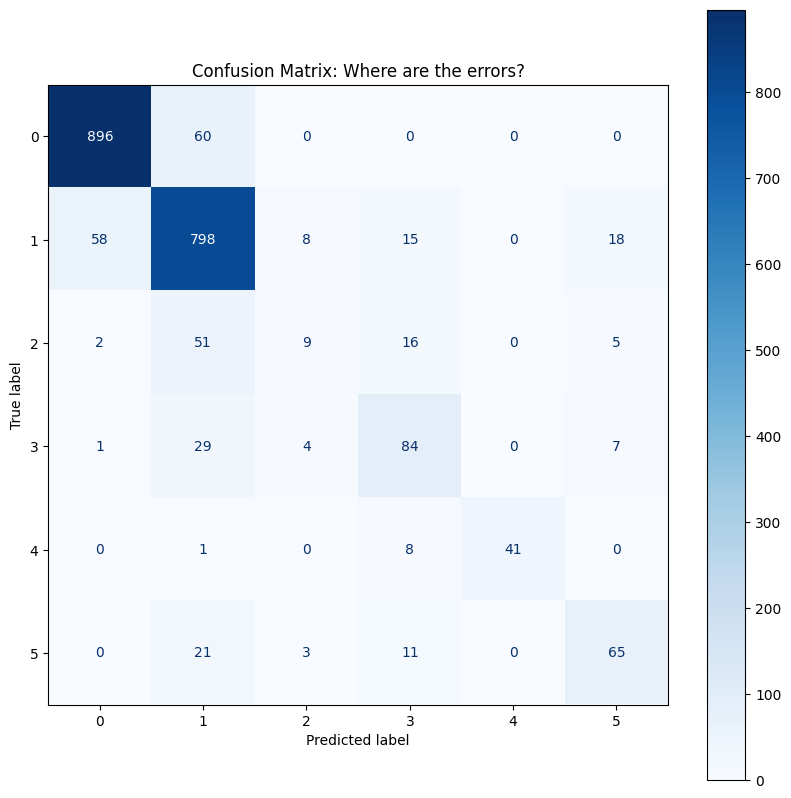


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9367 (Support: 956.0)
Label 1: F1 = 0.8595 (Support: 897.0)
Label 2: F1 = 0.1682 (Support: 83.0)
Label 3: F1 = 0.6486 (Support: 125.0)
Label 4: F1 = 0.9011 (Support: 50.0)
Label 5: F1 = 0.6667 (Support: 100.0)


In [32]:
# Adding new features to capture the dynamic activity and this serves as baseline 3
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = df[col].diff().abs().mean()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0
    
    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.7,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)

    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")

In [33]:
test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):

    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):

        df = pd.read_csv(csv_file)

        df["source_file"] = os.path.basename(csv_file)

        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

print(test_rows.shape)
test_rows.head()

print("Training Final Model on 100% of Data...")
lgbm_model.fit(X, y)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

print("Predicting Test Probabilities...")
test_raw_probs = lgbm_model.predict_proba(X_test)
test_preds = np.argmax(test_raw_probs, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")

(2054700, 9)
Training Final Model on 100% of Data...
Predicting Test Probabilities...
submission.csv successfully generated.



Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6617


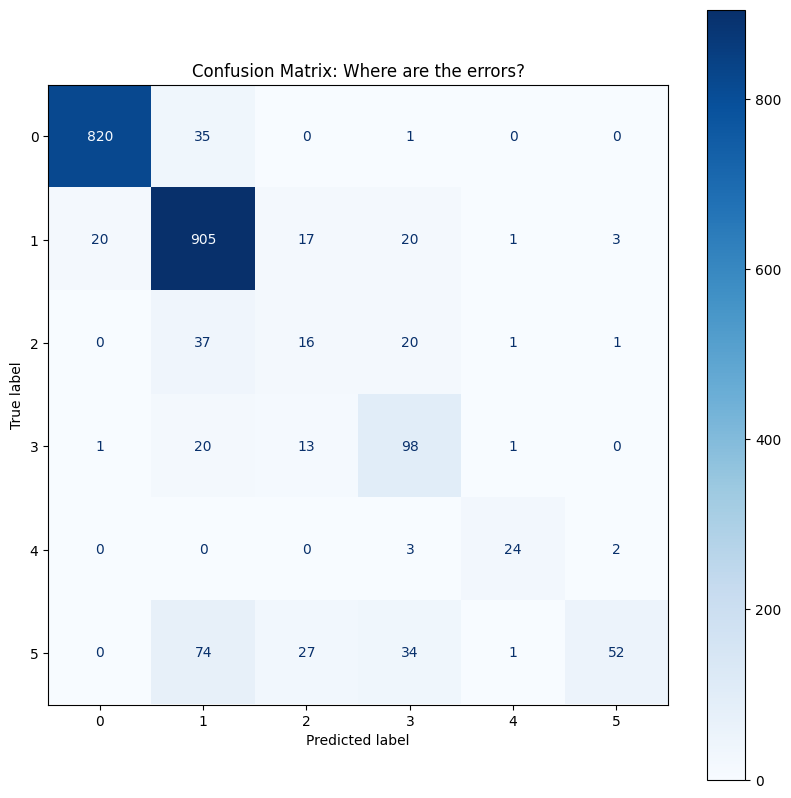


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9664 (Support: 856.0)
Label 1: F1 = 0.8886 (Support: 966.0)
Label 2: F1 = 0.2162 (Support: 75.0)
Label 3: F1 = 0.6343 (Support: 133.0)
Label 4: F1 = 0.8421 (Support: 29.0)
Label 5: F1 = 0.4228 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.7109


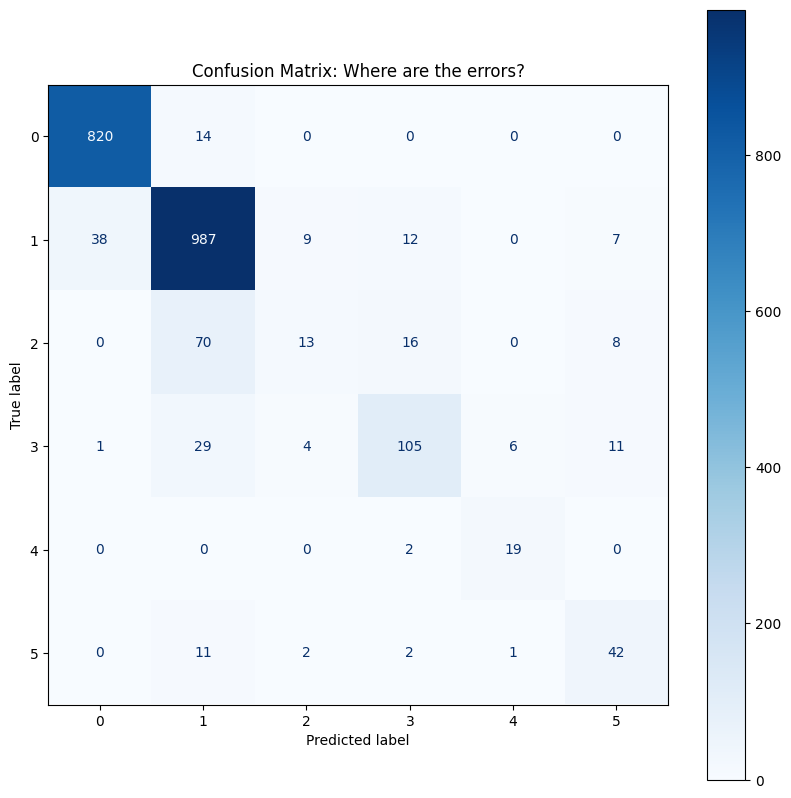


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9687 (Support: 834.0)
Label 1: F1 = 0.9122 (Support: 1053.0)
Label 2: F1 = 0.1926 (Support: 107.0)
Label 3: F1 = 0.7167 (Support: 156.0)
Label 4: F1 = 0.8085 (Support: 21.0)
Label 5: F1 = 0.6667 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7606


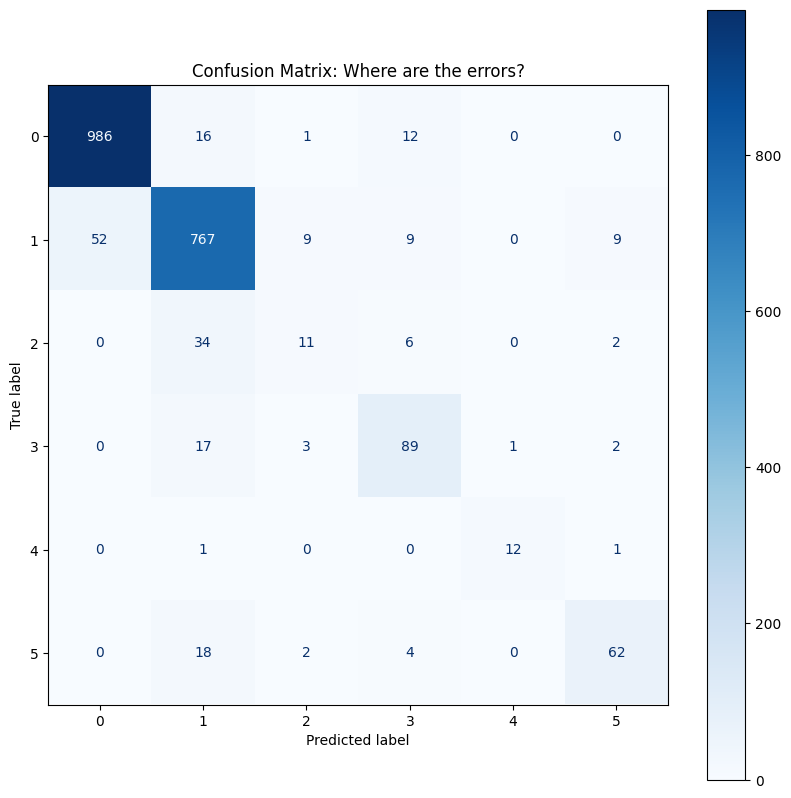


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9605 (Support: 1015.0)
Label 1: F1 = 0.9029 (Support: 846.0)
Label 2: F1 = 0.2785 (Support: 53.0)
Label 3: F1 = 0.7672 (Support: 112.0)
Label 4: F1 = 0.8889 (Support: 14.0)
Label 5: F1 = 0.7654 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7666


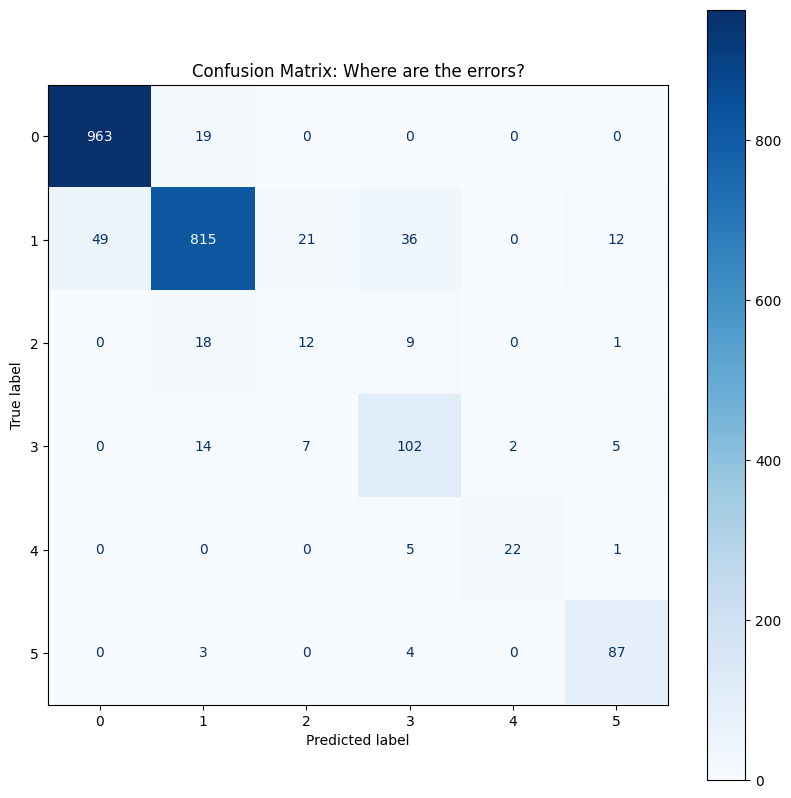


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9659 (Support: 982.0)
Label 1: F1 = 0.9046 (Support: 933.0)
Label 2: F1 = 0.3000 (Support: 40.0)
Label 3: F1 = 0.7133 (Support: 130.0)
Label 4: F1 = 0.8462 (Support: 28.0)
Label 5: F1 = 0.8700 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.7121


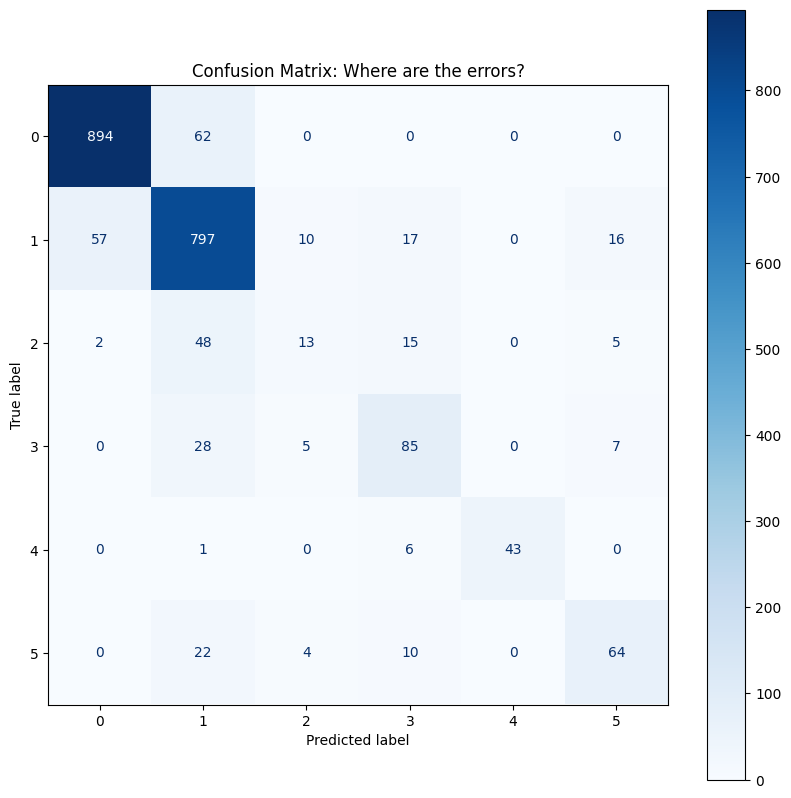


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9366 (Support: 956.0)
Label 1: F1 = 0.8593 (Support: 897.0)
Label 2: F1 = 0.2261 (Support: 83.0)
Label 3: F1 = 0.6589 (Support: 125.0)
Label 4: F1 = 0.9247 (Support: 50.0)
Label 5: F1 = 0.6667 (Support: 100.0)
(2054700, 9)
Training Final Model on 100% of Data...
Predicting Test Probabilities...
submission.csv successfully generated.


In [41]:
# Addition of Zero-Crossing-Rate feature and changes of all-axis w.r.t. the total magnitude
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = df[col].diff().abs().mean()
        feats[f"range_{col}"] = df[col].max() - df[col].min()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0

    for col in ["mean_x", "mean_y", "mean_z"]:
        diff_series = df[col].diff().dropna() - df[col].diff().dropna().mean()
        # Count how many times the signal passes zero line
        zcr = np.nonzero(np.diff(np.sign(diff_series)))[0].size / (len(df) + 1e-6)
        feats[f"{col}_jerk_zcr"] = zcr
        
    feats["gravity_dominance_x"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_y"] = feats["mean_y_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_z"] = feats["mean_z_mean"] / (feats["mag_mean_mean"] + 1e-6)

    feats["x_to_mag_ratio"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)

    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.7,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    # Execute the test for missing labels
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)

    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")

test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):

    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):

        df = pd.read_csv(csv_file)

        df["source_file"] = os.path.basename(csv_file)

        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

print(test_rows.shape)
test_rows.head()

print("Training Final Model on 100% of Data...")
lgbm_model.fit(X, y)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

print("Predicting Test Probabilities...")
test_raw_probs = lgbm_model.predict_proba(X_test)
test_preds = np.argmax(test_raw_probs, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")

In [26]:
# ENSEMBLED CROSS-VALIDATION LOOP WITH EARLY STOPPING import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = df[col].diff().abs().mean()
        feats[f"range_{col}"] = df[col].max() - df[col].min()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0

    for col in ["mean_x", "mean_y", "mean_z"]:
        diff_series = df[col].diff().dropna() - df[col].diff().dropna().mean()
        # Count how many times the signal passes zero line
        zcr = np.nonzero(np.diff(np.sign(diff_series)))[0].size / (len(df) + 1e-6)
        feats[f"{col}_jerk_zcr"] = zcr
        
    feats["gravity_dominance_x"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_y"] = feats["mean_y_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_z"] = feats["mean_z_mean"] / (feats["mag_mean_mean"] + 1e-6)

    feats["x_to_mag_ratio"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)

    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):
    user = os.path.basename(user_folder)
    for csv_file in glob(os.path.join(user_folder, '*.csv')):
        df = pd.read_csv(csv_file)
        df["source_file"] = os.path.basename(csv_file)
        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

test_probs_ensemble = np.zeros((len(X_test), 6))
fold_scores = []

print("Beginning Ensembled Fold Training...")

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    # Tuned hyperparameters focused on generalization and regularization
    fold_model = lgb.LGBMClassifier(
        n_estimators=1500,        # Increased max iterations to allow early stopping space
        learning_rate=0.01,
        num_leaves=31,
        class_weight='balanced',
        colsample_bytree=0.7,
        random_state=42 + fold,   # Varying random state per fold increases ensemble diversity
        verbose=-1
    )
    
    # Fit using early stopping to capture optimal iteration before validation decay
    fold_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    pred = fold_model.predict(X_va)
    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    print(f"Fold {fold+1} Macro F1: {score:.4f} (Best Iteration: {fold_model.best_iteration_})")
    
    test_probs_ensemble += fold_model.predict_proba(X_test) / sgkf.n_splits

print(f"\nMean CV Macro F1: {np.mean(fold_scores):.4f}")

print("Extracting Final Ensembled Predictions...")
test_preds = np.argmax(test_probs_ensemble, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission_OOF_Ensemble.csv", index=False)
print("submission_OOF_Ensembl.csv successfully generated via out-of-fold ensembling.")

Beginning Ensembled Fold Training...
Fold 1 Macro F1: 0.6806 (Best Iteration: 319)
Fold 2 Macro F1: 0.7023 (Best Iteration: 457)
Fold 3 Macro F1: 0.7624 (Best Iteration: 575)
Fold 4 Macro F1: 0.7620 (Best Iteration: 628)
Fold 5 Macro F1: 0.7191 (Best Iteration: 483)

Mean CV Macro F1: 0.7253
Extracting Final Ensembled Predictions...
submission_OOF_Ensembl.csv successfully generated via out-of-fold ensembling.


In [29]:
# THRESHOLD MULTIPLIER OPTIMIZATION
oof_train_probs = np.zeros((len(X), 6))
test_probs_ensemble = np.zeros((len(X_test), 6))
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    fold_model = lgb.LGBMClassifier(
        n_estimators=1500,        
        learning_rate=0.01,
        num_leaves=31,
        class_weight='balanced',
        colsample_bytree=0.7,
        random_state=42 + fold,   
        verbose=-1
    )
    
    fold_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    oof_train_probs[va_idx] = fold_model.predict_proba(X_va)
    
    pred = fold_model.predict(X_va)
    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    test_probs_ensemble += fold_model.predict_proba(X_test) / sgkf.n_splits

from scipy.optimize import minimize

print("\n--- Executing Step 2: Optimizing Class Multipliers ---")

def f1_optimization(weights):
    weighted_probs = oof_train_probs * weights
    preds = np.argmax(weighted_probs, axis=1)

    return -f1_score(y, preds, average='macro')

init_weights = [1.0] * 6
opt_result = minimize(f1_optimization, init_weights, method='Nelder-Mead', options={'maxiter': 500})
best_weights = opt_result.x

print(f"Optimized Class Multipliers: {best_weights}")
print(f"Original Train OOF Macro F1: {np.mean(fold_scores):.4f}")
print(f"Post-Optimization Train Macro F1: {-opt_result.fun:.4f}")

final_weighted_test_probs = test_probs_ensemble * best_weights
optimized_test_preds = np.argmax(final_weighted_test_probs, axis=1)

submission_opt = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": optimized_test_preds
})
submission_opt.to_csv("submission_OOF_with_thresholds.csv", index=False)
print("submission_OOF_with_thresholds.csv successfully generated.")


--- Executing Step 2: Optimizing Class Multipliers ---
Optimized Class Multipliers: [0.9972504  1.10698431 0.94248499 1.04083054 0.99646557 0.96172366]
Original Train OOF Macro F1: 0.7253
Post-Optimization Train Macro F1: 0.7270
submission_OOF_with_thresholds.csv successfully generated.


In [4]:
# Best performance of mine on the Public Leaderboard
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = df[col].diff().abs().mean()
        feats[f"range_{col}"] = df[col].max() - df[col].min()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0

    for col in ["mean_x", "mean_y", "mean_z"]:
        diff_series = df[col].diff().dropna() - df[col].diff().dropna().mean()
        # Count how many times the signal passes zero line
        zcr = np.nonzero(np.diff(np.sign(diff_series)))[0].size / (len(df) + 1e-6)
        feats[f"{col}_jerk_zcr"] = zcr
        
    feats["gravity_dominance_x"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_y"] = feats["mean_y_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_z"] = feats["mean_z_mean"] / (feats["mag_mean_mean"] + 1e-6)

    feats["x_to_mag_ratio"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)

    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]

test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):
    user = os.path.basename(user_folder)
    for csv_file in glob(os.path.join(user_folder, '*.csv')):
        df = pd.read_csv(csv_file)
        df["source_file"] = os.path.basename(csv_file)
        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

full_data_test_probs = np.zeros((len(X_test), 6))
seeds = [42, 123, 456, 789, 999]

print("Training 5 Seed Models on 100% of Training Data...")

for seed in seeds:
    print(f"--> Training Model with Seed {seed}...")
    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=31,
        class_weight='balanced',   
        colsample_bytree=0.7,
        random_state=seed,         
        verbose=-1
    )
    
    model.fit(X, y)
    full_data_test_probs += model.predict_proba(X_test) / len(seeds)

print("100% Data Ensemble Complete.")

seed_test_preds = np.argmax(full_data_test_probs, axis=1)

submission_seed = pd.DataFrame({"Id": test_df["file_id"], "Label": seed_test_preds})
submission_seed.to_csv("submission_seed_averaging.csv", index=False)
print("submission_seed_averaging.csv generated.")

Training 5 Seed Models on 100% of Training Data...
--> Training Model with Seed 42...
--> Training Model with Seed 123...
--> Training Model with Seed 456...
--> Training Model with Seed 789...
--> Training Model with Seed 999...
100% Data Ensemble Complete.
submission_seed_averaging.csv generated.


# Below only test cases which performs worse by adding more feature engineering and cannot outperform my current best in the Public Leaderboard #


Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6604


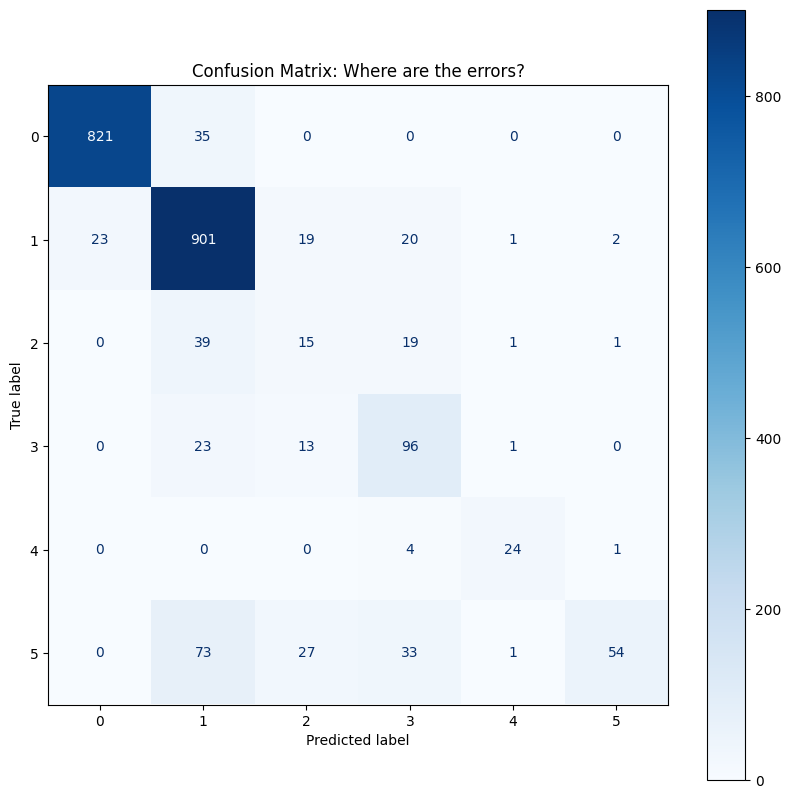


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9659 (Support: 856.0)
Label 1: F1 = 0.8846 (Support: 966.0)
Label 2: F1 = 0.2013 (Support: 75.0)
Label 3: F1 = 0.6295 (Support: 133.0)
Label 4: F1 = 0.8421 (Support: 29.0)
Label 5: F1 = 0.4390 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.6967


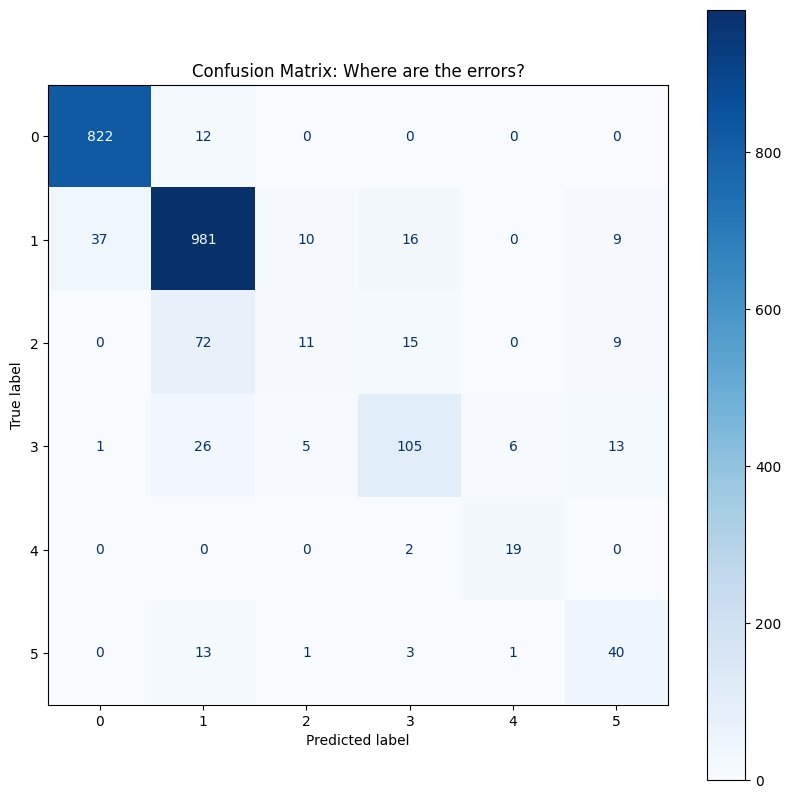


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9705 (Support: 834.0)
Label 1: F1 = 0.9096 (Support: 1053.0)
Label 2: F1 = 0.1642 (Support: 107.0)
Label 3: F1 = 0.7071 (Support: 156.0)
Label 4: F1 = 0.8085 (Support: 21.0)
Label 5: F1 = 0.6202 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7627


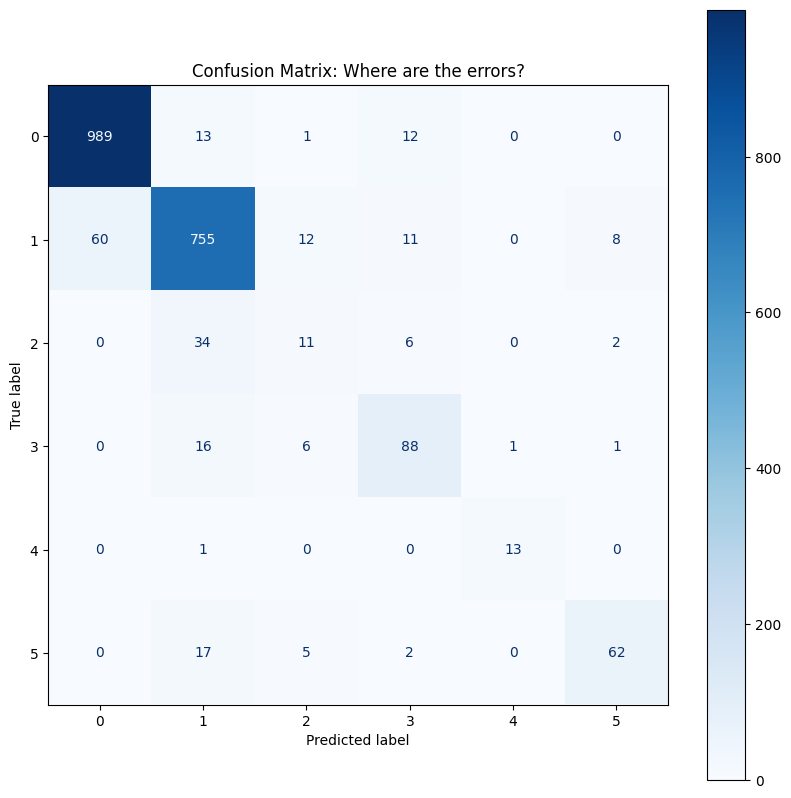


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9583 (Support: 1015.0)
Label 1: F1 = 0.8977 (Support: 846.0)
Label 2: F1 = 0.2500 (Support: 53.0)
Label 3: F1 = 0.7619 (Support: 112.0)
Label 4: F1 = 0.9286 (Support: 14.0)
Label 5: F1 = 0.7799 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7580


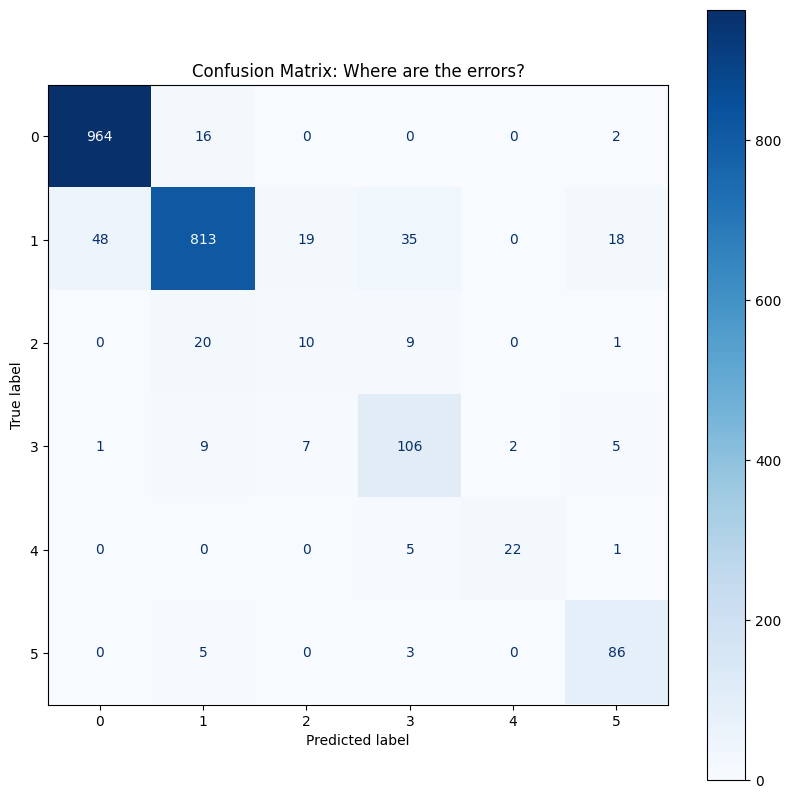


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9664 (Support: 982.0)
Label 1: F1 = 0.9053 (Support: 933.0)
Label 2: F1 = 0.2632 (Support: 40.0)
Label 3: F1 = 0.7361 (Support: 130.0)
Label 4: F1 = 0.8462 (Support: 28.0)
Label 5: F1 = 0.8309 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.6984


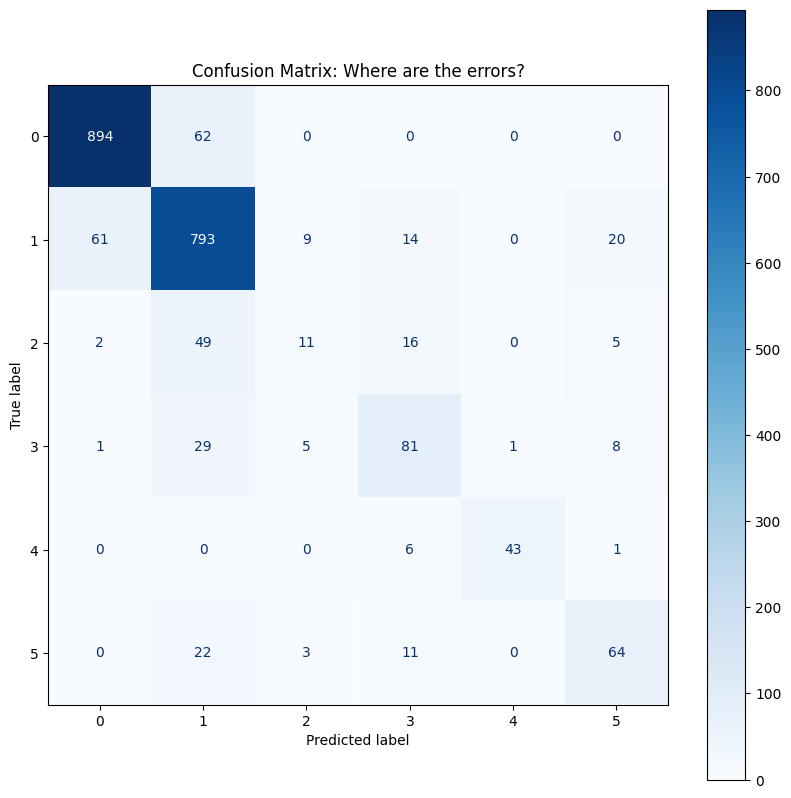


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9342 (Support: 956.0)
Label 1: F1 = 0.8564 (Support: 897.0)
Label 2: F1 = 0.1982 (Support: 83.0)
Label 3: F1 = 0.6403 (Support: 125.0)
Label 4: F1 = 0.9149 (Support: 50.0)
Label 5: F1 = 0.6465 (Support: 100.0)


In [28]:
# colsample_bytree set at 0.6 for baseline 2
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = df[col].diff().abs().mean()
    
    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.6,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)
    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")


Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6550


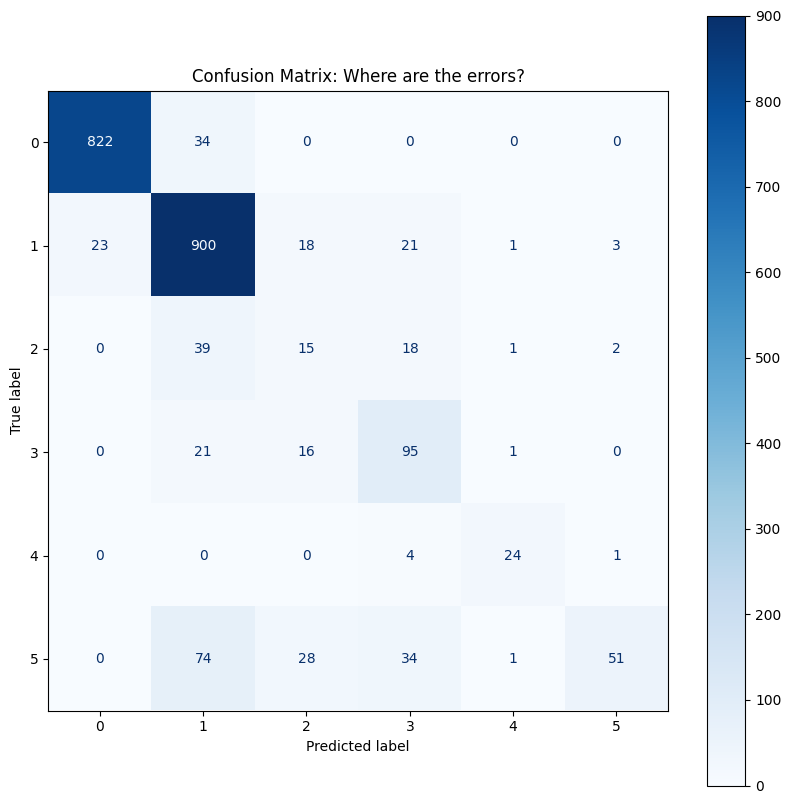


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9665 (Support: 856.0)
Label 1: F1 = 0.8850 (Support: 966.0)
Label 2: F1 = 0.1974 (Support: 75.0)
Label 3: F1 = 0.6230 (Support: 133.0)
Label 4: F1 = 0.8421 (Support: 29.0)
Label 5: F1 = 0.4163 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.6865


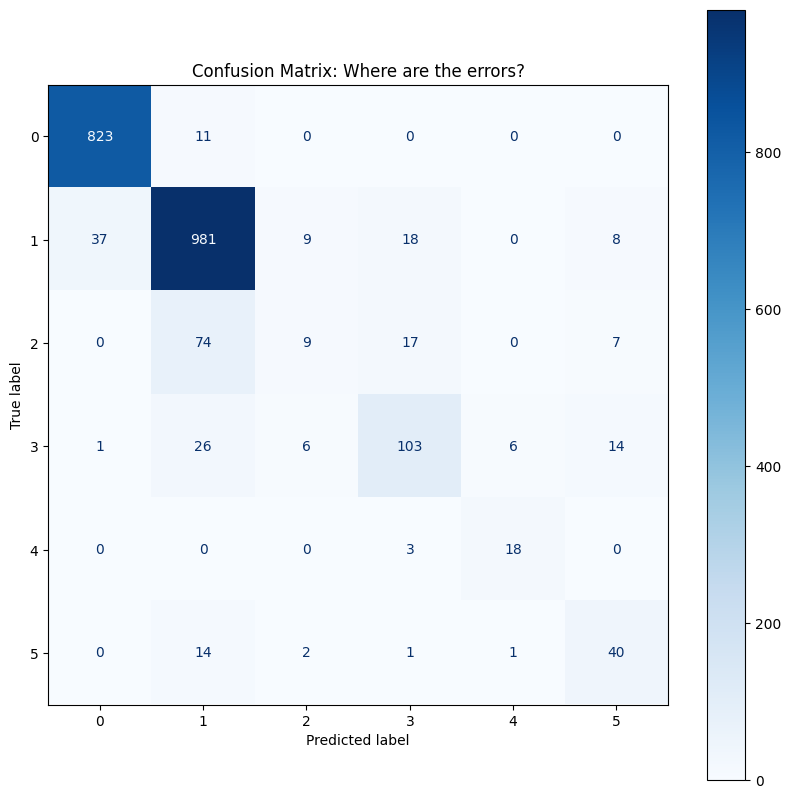


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9711 (Support: 834.0)
Label 1: F1 = 0.9088 (Support: 1053.0)
Label 2: F1 = 0.1353 (Support: 107.0)
Label 3: F1 = 0.6913 (Support: 156.0)
Label 4: F1 = 0.7826 (Support: 21.0)
Label 5: F1 = 0.6299 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7682


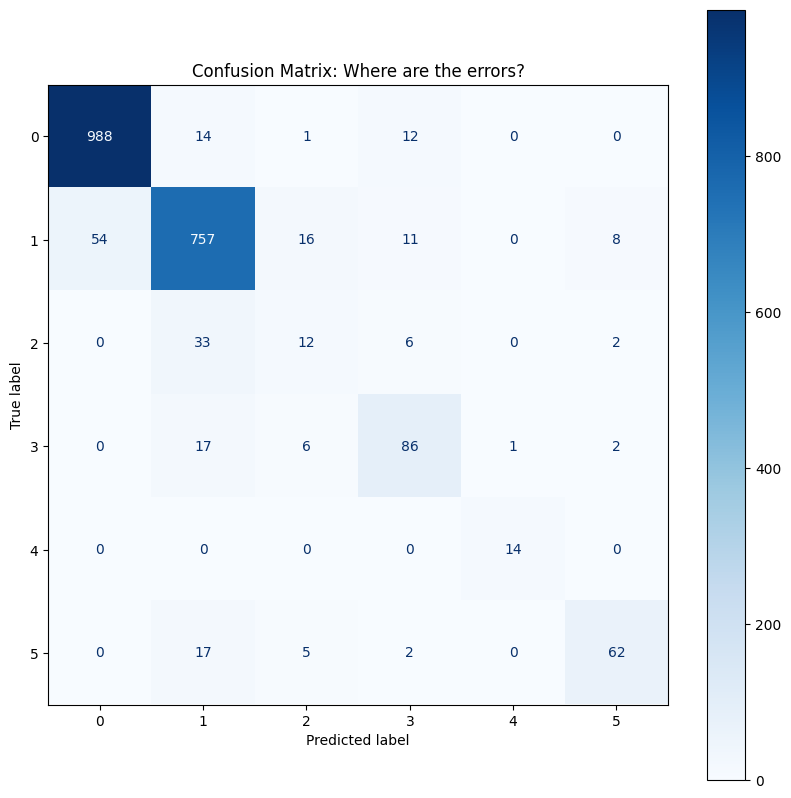


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9606 (Support: 1015.0)
Label 1: F1 = 0.8990 (Support: 846.0)
Label 2: F1 = 0.2581 (Support: 53.0)
Label 3: F1 = 0.7511 (Support: 112.0)
Label 4: F1 = 0.9655 (Support: 14.0)
Label 5: F1 = 0.7750 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7549


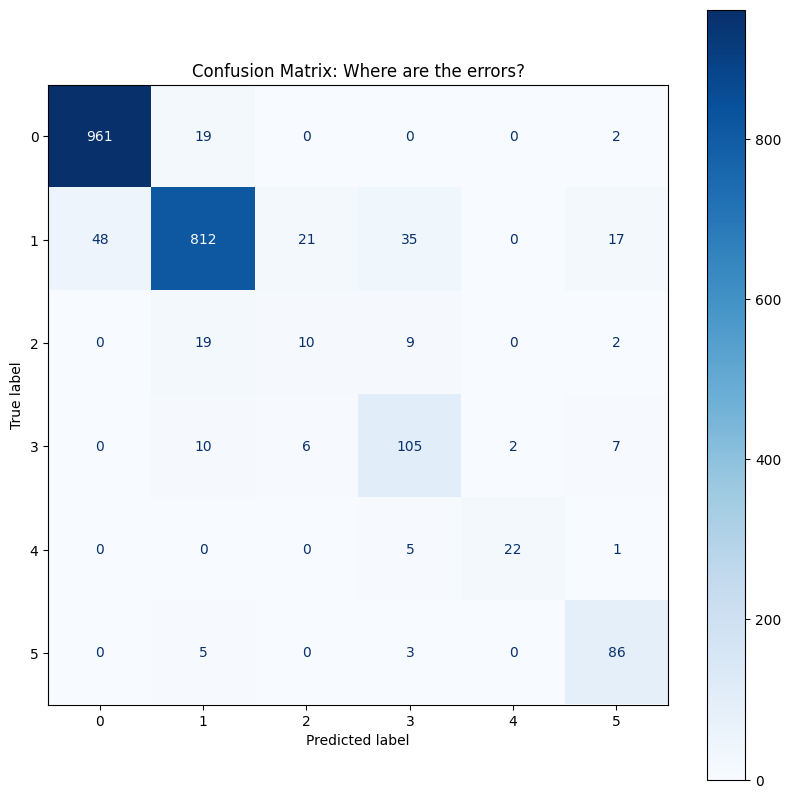


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9653 (Support: 982.0)
Label 1: F1 = 0.9032 (Support: 933.0)
Label 2: F1 = 0.2597 (Support: 40.0)
Label 3: F1 = 0.7317 (Support: 130.0)
Label 4: F1 = 0.8462 (Support: 28.0)
Label 5: F1 = 0.8230 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.6967


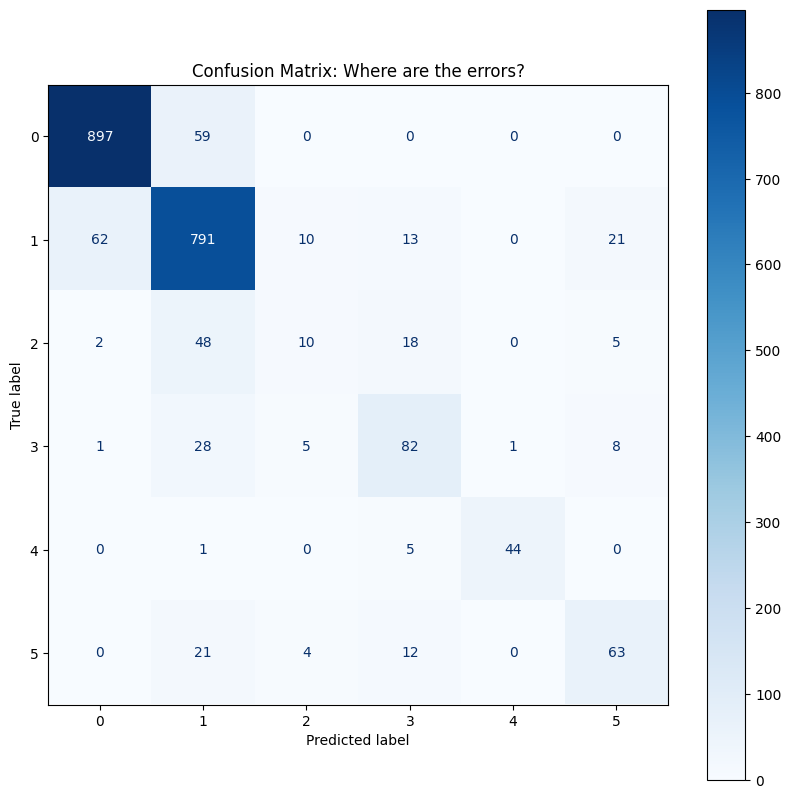


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9353 (Support: 956.0)
Label 1: F1 = 0.8575 (Support: 897.0)
Label 2: F1 = 0.1786 (Support: 83.0)
Label 3: F1 = 0.6431 (Support: 125.0)
Label 4: F1 = 0.9263 (Support: 50.0)
Label 5: F1 = 0.6396 (Support: 100.0)


In [30]:
# colsample_bytree set at 0.8 for baseline 2
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = df[col].diff().abs().mean()
    
    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.8,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)
    
    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")


Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6706


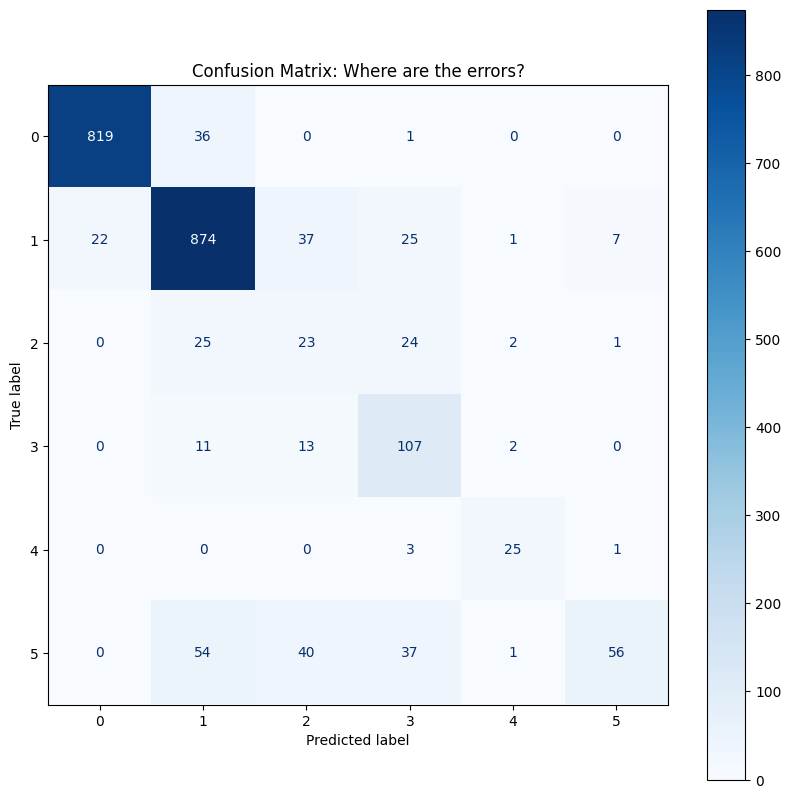


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9652 (Support: 856.0)
Label 1: F1 = 0.8891 (Support: 966.0)
Label 2: F1 = 0.2447 (Support: 75.0)
Label 3: F1 = 0.6485 (Support: 133.0)
Label 4: F1 = 0.8333 (Support: 29.0)
Label 5: F1 = 0.4427 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.7131


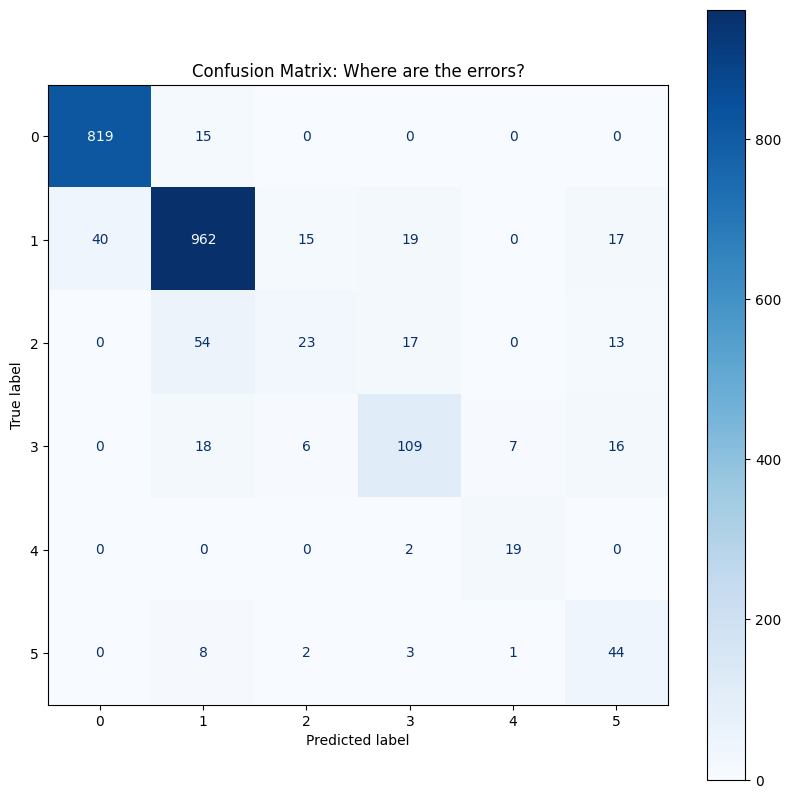


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9675 (Support: 834.0)
Label 1: F1 = 0.9118 (Support: 1053.0)
Label 2: F1 = 0.3007 (Support: 107.0)
Label 3: F1 = 0.7124 (Support: 156.0)
Label 4: F1 = 0.7917 (Support: 21.0)
Label 5: F1 = 0.5946 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7662


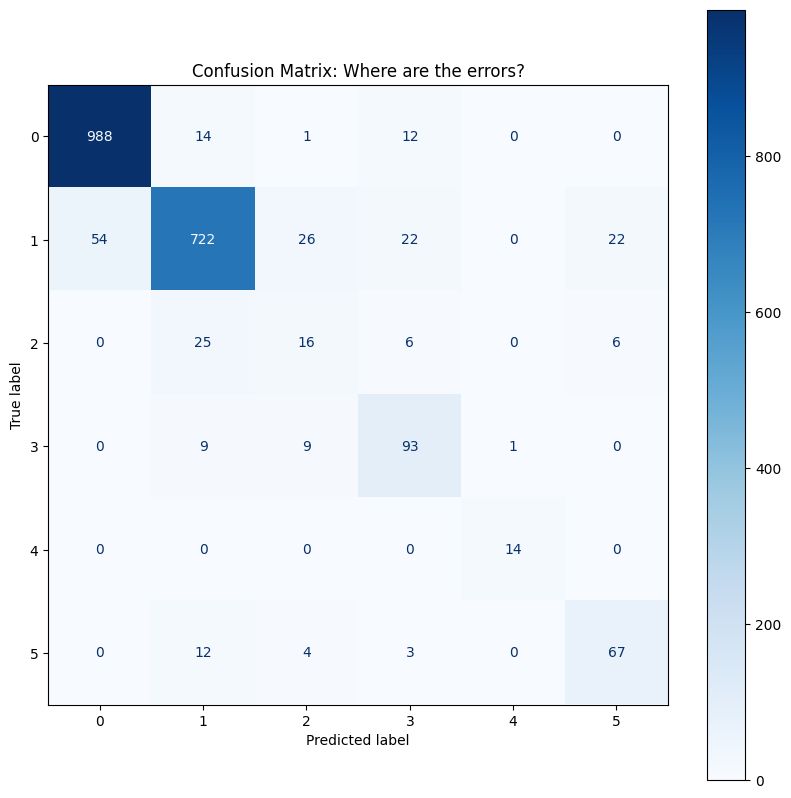


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9606 (Support: 1015.0)
Label 1: F1 = 0.8870 (Support: 846.0)
Label 2: F1 = 0.2936 (Support: 53.0)
Label 3: F1 = 0.7500 (Support: 112.0)
Label 4: F1 = 0.9655 (Support: 14.0)
Label 5: F1 = 0.7403 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7372


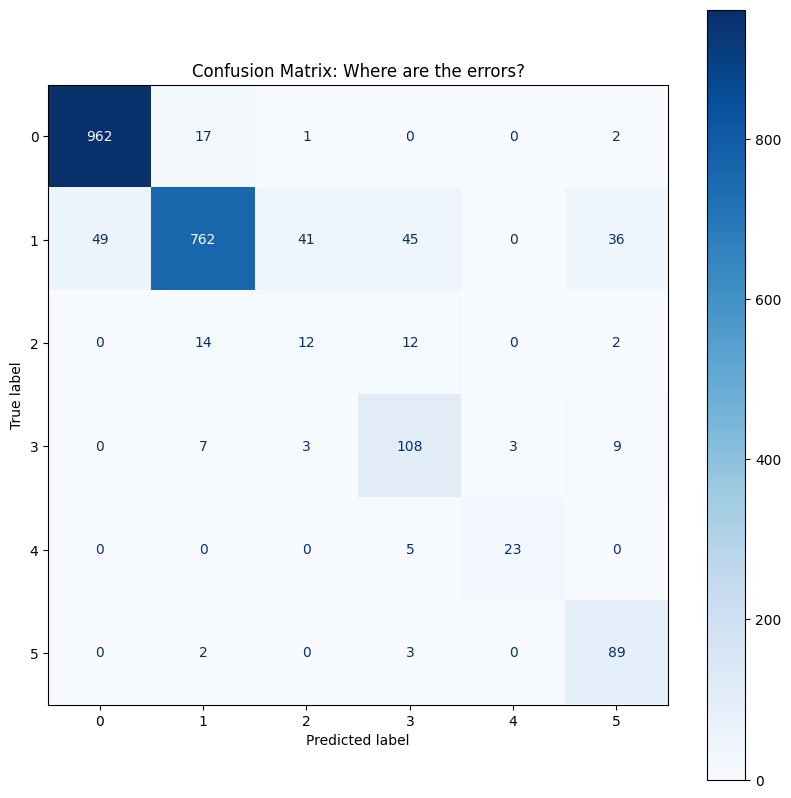


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9654 (Support: 982.0)
Label 1: F1 = 0.8784 (Support: 933.0)
Label 2: F1 = 0.2474 (Support: 40.0)
Label 3: F1 = 0.7129 (Support: 130.0)
Label 4: F1 = 0.8519 (Support: 28.0)
Label 5: F1 = 0.7672 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.7187


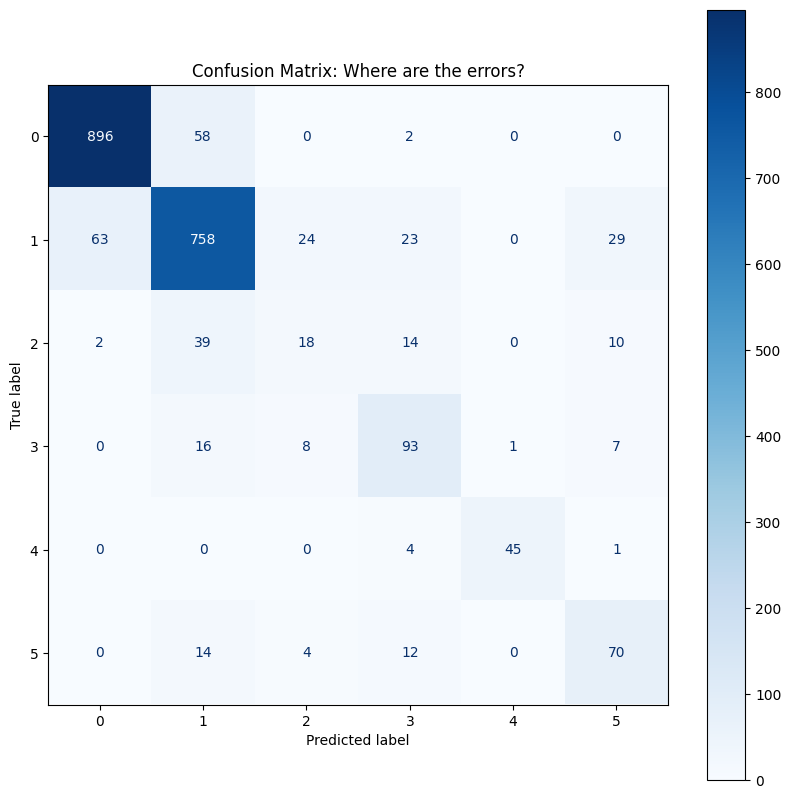


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9348 (Support: 956.0)
Label 1: F1 = 0.8507 (Support: 897.0)
Label 2: F1 = 0.2628 (Support: 83.0)
Label 3: F1 = 0.6813 (Support: 125.0)
Label 4: F1 = 0.9375 (Support: 50.0)
Label 5: F1 = 0.6452 (Support: 100.0)


In [34]:
# Adding Subsample, L1 and L2 to baseline 3
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = df[col].diff().abs().mean()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0
    
    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.7,
    subsample=0.8,
    subsample_freq=1,
    reg_lambda=10.0,
    reg_alpha=2.0,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)

    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")


Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6736


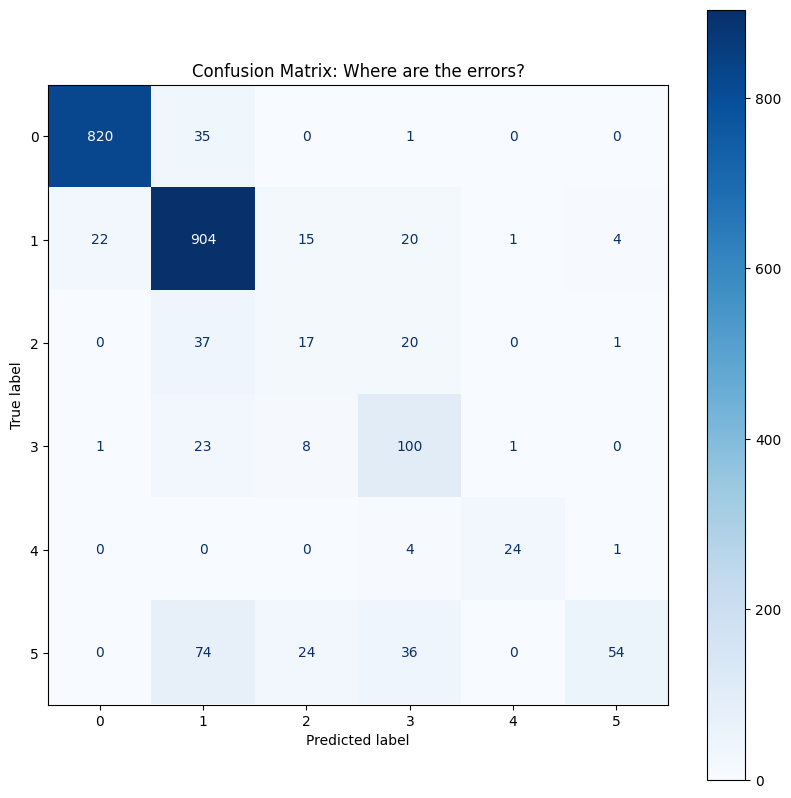


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9653 (Support: 856.0)
Label 1: F1 = 0.8867 (Support: 966.0)
Label 2: F1 = 0.2446 (Support: 75.0)
Label 3: F1 = 0.6369 (Support: 133.0)
Label 4: F1 = 0.8727 (Support: 29.0)
Label 5: F1 = 0.4355 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.7059


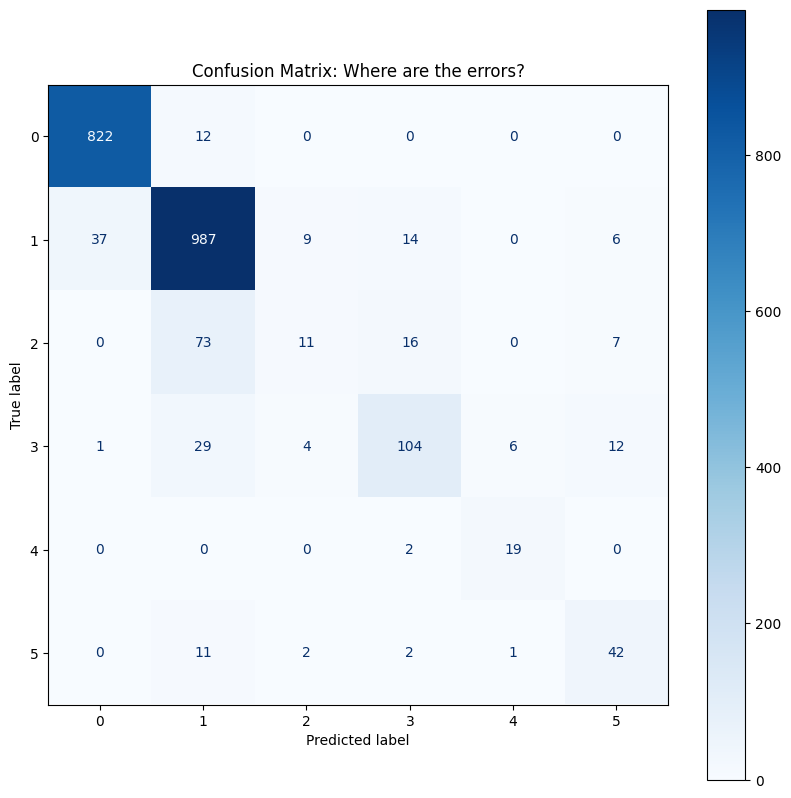


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9705 (Support: 834.0)
Label 1: F1 = 0.9118 (Support: 1053.0)
Label 2: F1 = 0.1654 (Support: 107.0)
Label 3: F1 = 0.7075 (Support: 156.0)
Label 4: F1 = 0.8085 (Support: 21.0)
Label 5: F1 = 0.6720 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7518


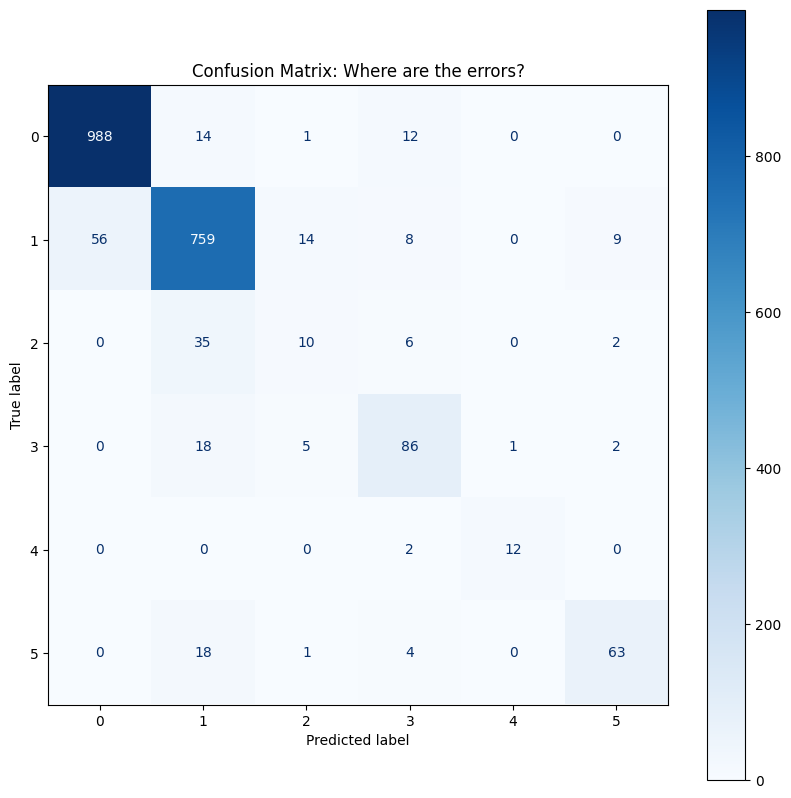


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9597 (Support: 1015.0)
Label 1: F1 = 0.8982 (Support: 846.0)
Label 2: F1 = 0.2381 (Support: 53.0)
Label 3: F1 = 0.7478 (Support: 112.0)
Label 4: F1 = 0.8889 (Support: 14.0)
Label 5: F1 = 0.7778 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7760


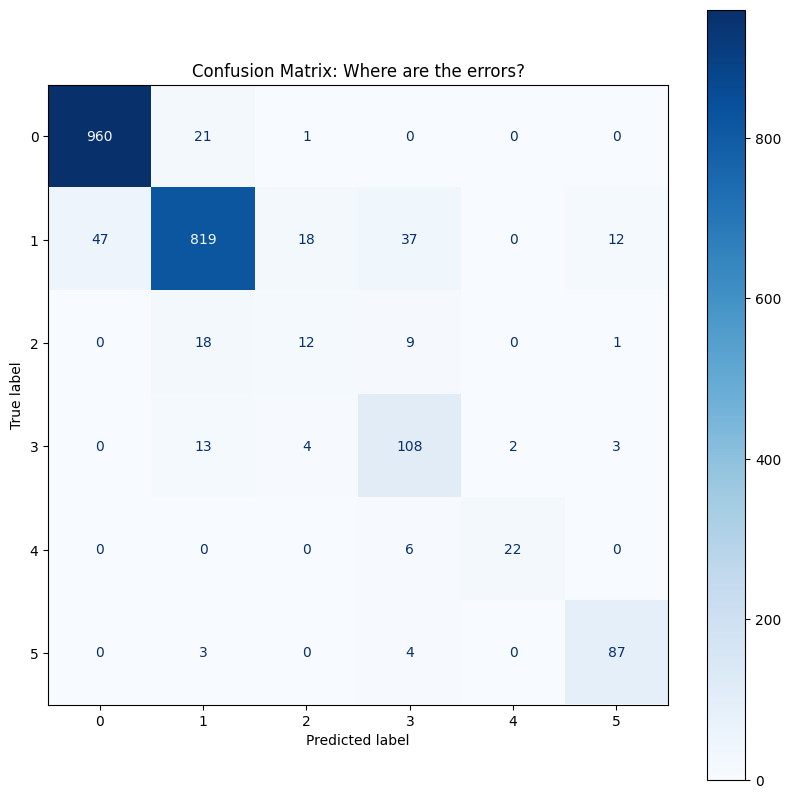


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9653 (Support: 982.0)
Label 1: F1 = 0.9065 (Support: 933.0)
Label 2: F1 = 0.3200 (Support: 40.0)
Label 3: F1 = 0.7347 (Support: 130.0)
Label 4: F1 = 0.8462 (Support: 28.0)
Label 5: F1 = 0.8832 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.7106


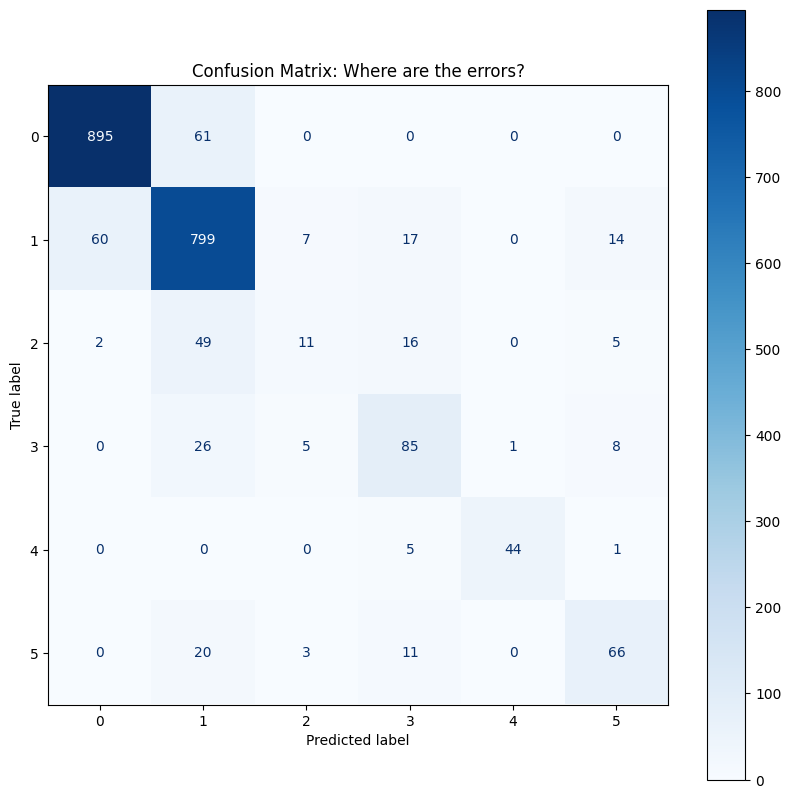


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9357 (Support: 956.0)
Label 1: F1 = 0.8629 (Support: 897.0)
Label 2: F1 = 0.2018 (Support: 83.0)
Label 3: F1 = 0.6564 (Support: 125.0)
Label 4: F1 = 0.9263 (Support: 50.0)
Label 5: F1 = 0.6804 (Support: 100.0)
(2054700, 9)
Training Final Model on 100% of Data...
Predicting Test Probabilities...
submission.csv successfully generated.


In [24]:
# Addition of Signal Granularity Feature to baseline 3
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    df = df.copy()
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        series = df[col]
        feats[f"{col}_mean"] = series.mean()
        feats[f"{col}_std"] = series.std()
        feats[f"{col}_min"] = series.min()
        feats[f"{col}_max"] = series.max()
        feats[f"{col}_median"] = series.median()
        feats[f"{col}_q25"] = series.quantile(0.25)
        feats[f"{col}_q75"] = series.quantile(0.75)
        feats[f"{col}_mean_trends"] = series.diff().abs().mean()
        feats[f"range_{col}"] = series.max() - series.min()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0

    for col in ["mean_x", "mean_y", "mean_z"]:
        diff_series = df[col].diff().dropna() - df[col].diff().dropna().mean()
        zcr = np.nonzero(np.diff(np.sign(diff_series)))[0].size / (len(df) + 1e-6)
        feats[f"{col}_jerk_zcr"] = zcr
        
    feats["gravity_dominance_x"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_y"] = feats["mean_y_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_z"] = feats["mean_z_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["x_to_mag_ratio"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)

    # ADDED SIGNAL REGULARITY
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        series = df[col]
        if len(series) > 5:
            feats[f"{col}_autocorr_1"] = series.autocorr(lag=1)
            feats[f"{col}_autocorr_2"] = series.autocorr(lag=2)
            feats[f"{col}_rolling_energy"] = series.diff().var()
        else:
            feats[f"{col}_autocorr_1"] = 0
            feats[f"{col}_autocorr_2"] = 0
            feats[f"{col}_rolling_energy"] = 0

    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.7,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)

    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")

test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):
    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):
        df = pd.read_csv(csv_file)
        df["source_file"] = os.path.basename(csv_file)
        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

print(test_rows.shape)
test_rows.head()

print("Training Final Model on 100% of Data...")
lgbm_model.fit(X, y)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

print("Predicting Test Probabilities...")
test_raw_probs = lgbm_model.predict_proba(X_test)
test_preds = np.argmax(test_raw_probs, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")


Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6750


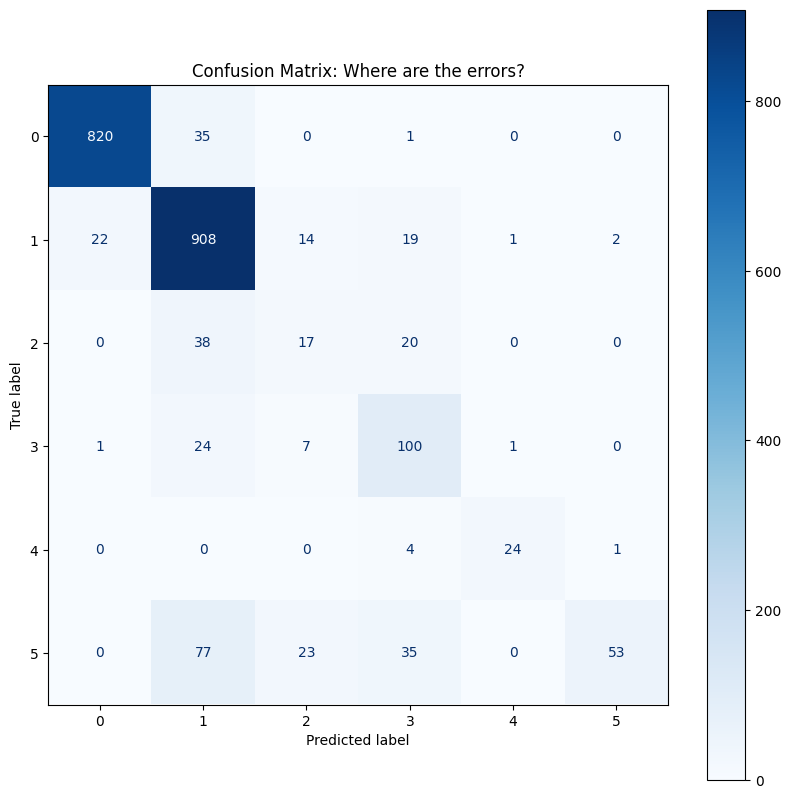


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9653 (Support: 856.0)
Label 1: F1 = 0.8867 (Support: 966.0)
Label 2: F1 = 0.2500 (Support: 75.0)
Label 3: F1 = 0.6410 (Support: 133.0)
Label 4: F1 = 0.8727 (Support: 29.0)
Label 5: F1 = 0.4344 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.7025


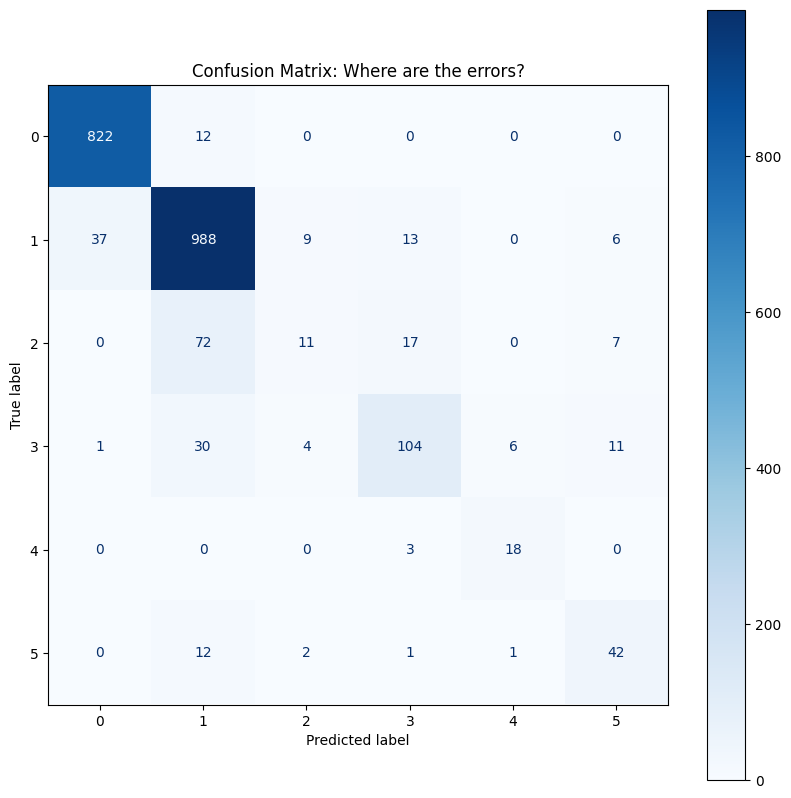


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9705 (Support: 834.0)
Label 1: F1 = 0.9119 (Support: 1053.0)
Label 2: F1 = 0.1654 (Support: 107.0)
Label 3: F1 = 0.7075 (Support: 156.0)
Label 4: F1 = 0.7826 (Support: 21.0)
Label 5: F1 = 0.6774 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7607


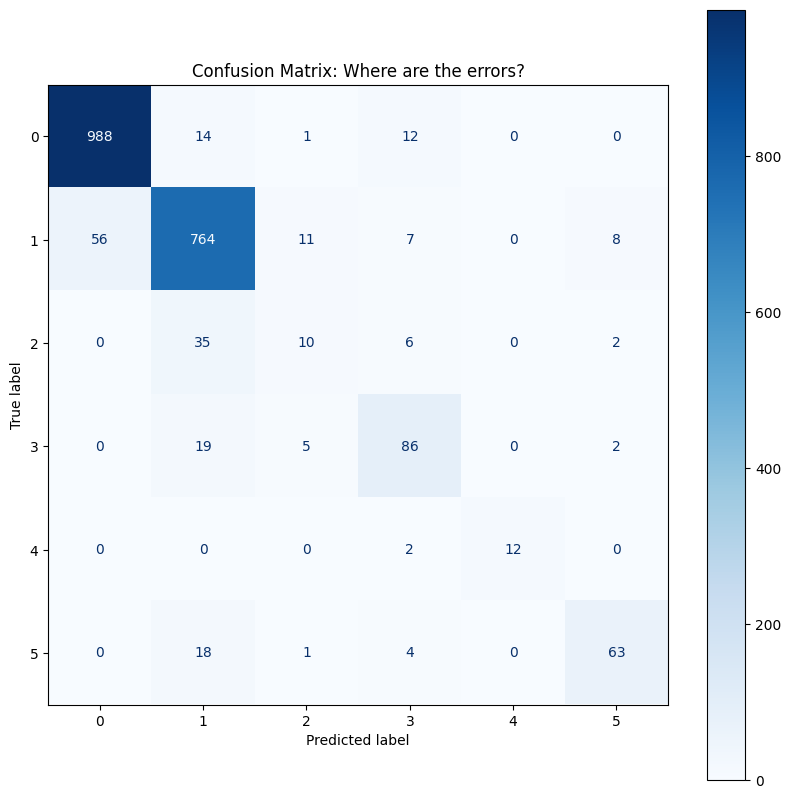


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9597 (Support: 1015.0)
Label 1: F1 = 0.9009 (Support: 846.0)
Label 2: F1 = 0.2469 (Support: 53.0)
Label 3: F1 = 0.7511 (Support: 112.0)
Label 4: F1 = 0.9231 (Support: 14.0)
Label 5: F1 = 0.7826 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7831


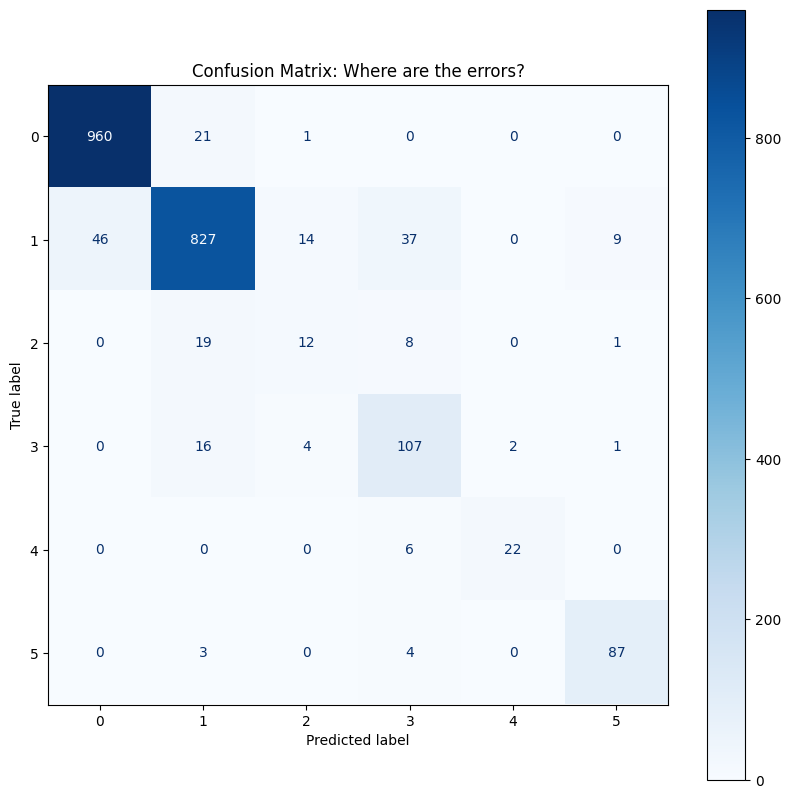


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9658 (Support: 982.0)
Label 1: F1 = 0.9093 (Support: 933.0)
Label 2: F1 = 0.3380 (Support: 40.0)
Label 3: F1 = 0.7329 (Support: 130.0)
Label 4: F1 = 0.8462 (Support: 28.0)
Label 5: F1 = 0.9062 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.7112


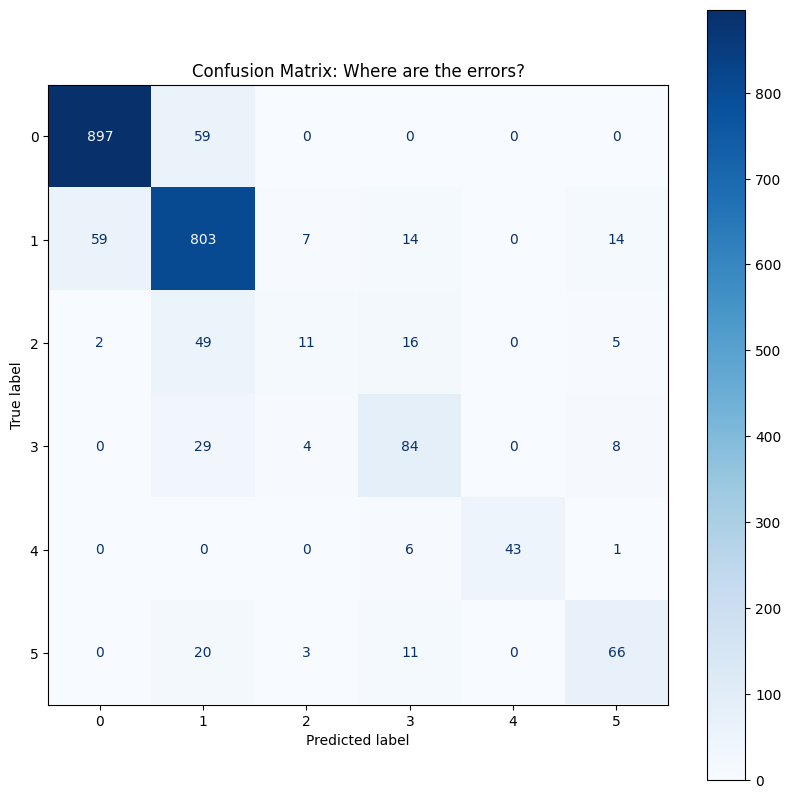


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9373 (Support: 956.0)
Label 1: F1 = 0.8648 (Support: 897.0)
Label 2: F1 = 0.2037 (Support: 83.0)
Label 3: F1 = 0.6562 (Support: 125.0)
Label 4: F1 = 0.9247 (Support: 50.0)
Label 5: F1 = 0.6804 (Support: 100.0)
(2054700, 9)
Training Final Model on 100% of Data...
Predicting Test Probabilities...
submission.csv successfully generated.


In [44]:
# Addition of Signal Granularity Feature + n_estimator = 1100 of baseline 3
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    df = df.copy()
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        series = df[col]
        feats[f"{col}_mean"] = series.mean()
        feats[f"{col}_std"] = series.std()
        feats[f"{col}_min"] = series.min()
        feats[f"{col}_max"] = series.max()
        feats[f"{col}_median"] = series.median()
        feats[f"{col}_q25"] = series.quantile(0.25)
        feats[f"{col}_q75"] = series.quantile(0.75)
        feats[f"{col}_mean_trends"] = series.diff().abs().mean()
        feats[f"range_{col}"] = series.max() - series.min()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0

    for col in ["mean_x", "mean_y", "mean_z"]:
        diff_series = df[col].diff().dropna() - df[col].diff().dropna().mean()
        zcr = np.nonzero(np.diff(np.sign(diff_series)))[0].size / (len(df) + 1e-6)
        feats[f"{col}_jerk_zcr"] = zcr
        
    feats["gravity_dominance_x"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_y"] = feats["mean_y_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_z"] = feats["mean_z_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["x_to_mag_ratio"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)

    # ADDED SIGNAL REGULARITY
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        series = df[col]
        if len(series) > 5:
            feats[f"{col}_autocorr_1"] = series.autocorr(lag=1)
            feats[f"{col}_autocorr_2"] = series.autocorr(lag=2)
            feats[f"{col}_rolling_energy"] = series.diff().var()
        else:
            feats[f"{col}_autocorr_1"] = 0
            feats[f"{col}_autocorr_2"] = 0
            feats[f"{col}_rolling_energy"] = 0

    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1100,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.7,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)

    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")

test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):

    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):

        df = pd.read_csv(csv_file)

        df["source_file"] = os.path.basename(csv_file)

        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

print(test_rows.shape)
test_rows.head()

print("Training Final Model on 100% of Data...")
lgbm_model.fit(X, y)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

print("Predicting Test Probabilities...")
test_raw_probs = lgbm_model.predict_proba(X_test)
test_preds = np.argmax(test_raw_probs, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")


Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6699


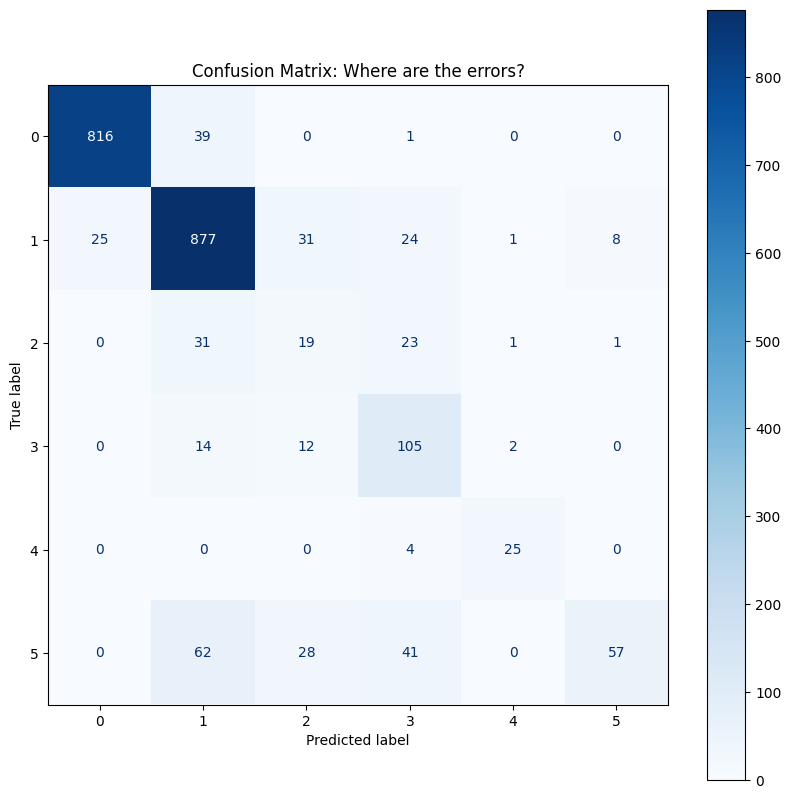


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9617 (Support: 856.0)
Label 1: F1 = 0.8819 (Support: 966.0)
Label 2: F1 = 0.2303 (Support: 75.0)
Label 3: F1 = 0.6344 (Support: 133.0)
Label 4: F1 = 0.8621 (Support: 29.0)
Label 5: F1 = 0.4488 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.7157


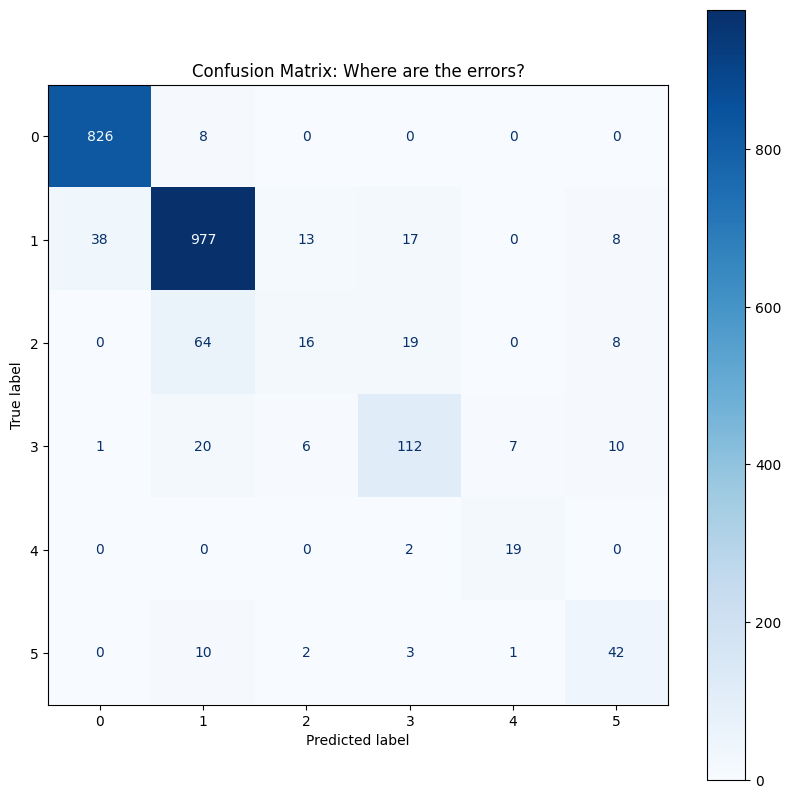


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9723 (Support: 834.0)
Label 1: F1 = 0.9165 (Support: 1053.0)
Label 2: F1 = 0.2222 (Support: 107.0)
Label 3: F1 = 0.7249 (Support: 156.0)
Label 4: F1 = 0.7917 (Support: 21.0)
Label 5: F1 = 0.6667 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7660


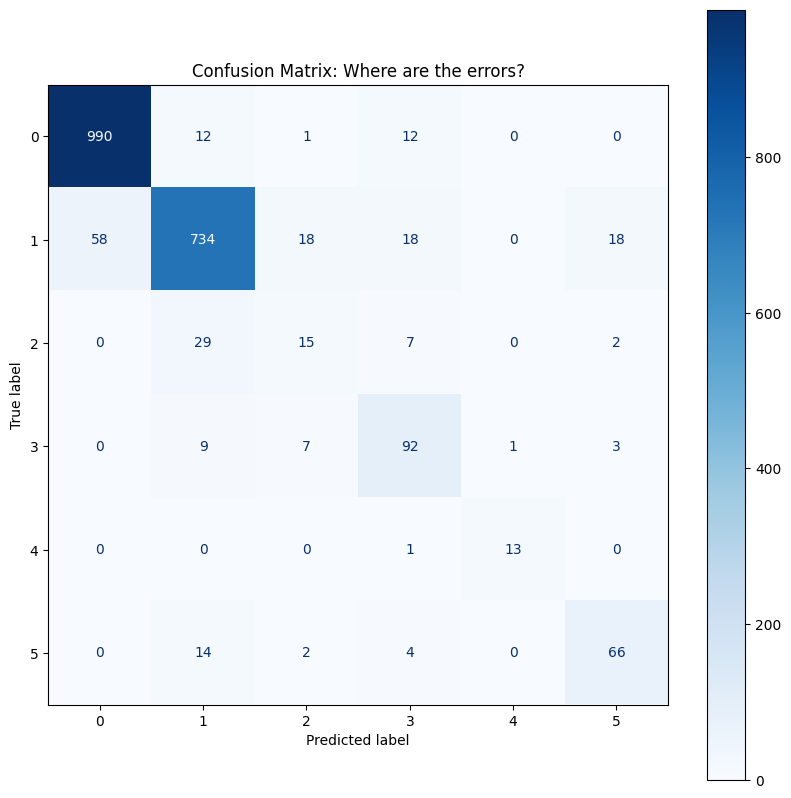


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9598 (Support: 1015.0)
Label 1: F1 = 0.8929 (Support: 846.0)
Label 2: F1 = 0.3125 (Support: 53.0)
Label 3: F1 = 0.7480 (Support: 112.0)
Label 4: F1 = 0.9286 (Support: 14.0)
Label 5: F1 = 0.7543 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7570


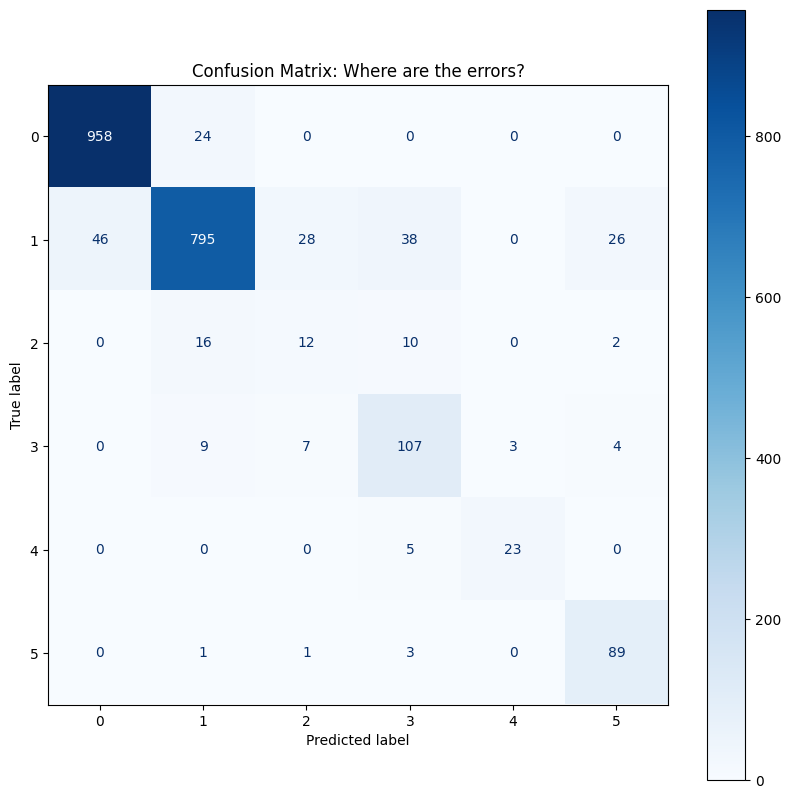


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9648 (Support: 982.0)
Label 1: F1 = 0.8943 (Support: 933.0)
Label 2: F1 = 0.2727 (Support: 40.0)
Label 3: F1 = 0.7304 (Support: 130.0)
Label 4: F1 = 0.8519 (Support: 28.0)
Label 5: F1 = 0.8279 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.7009


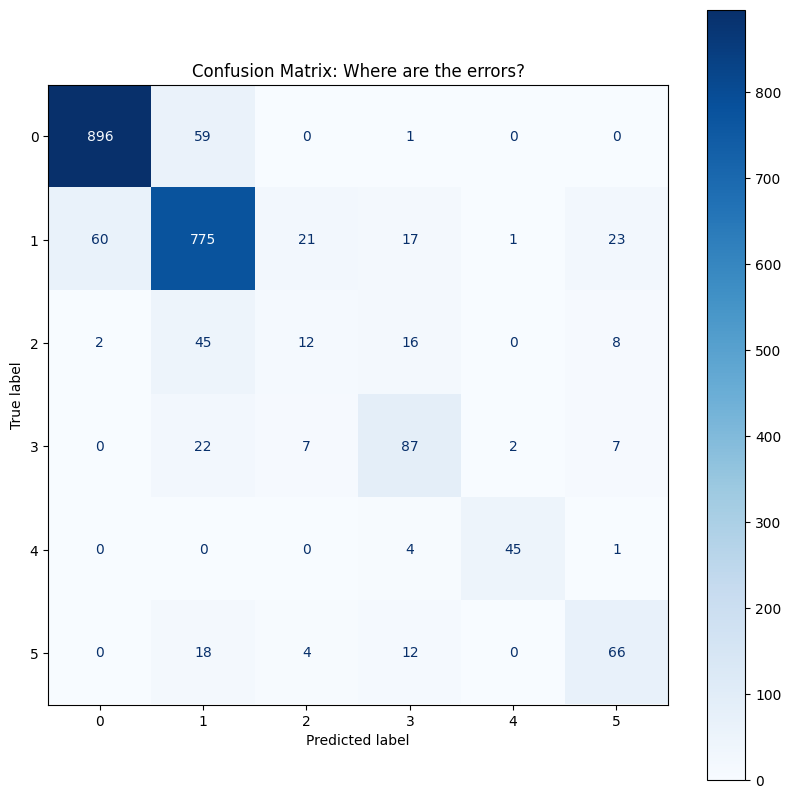


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9363 (Support: 956.0)
Label 1: F1 = 0.8535 (Support: 897.0)
Label 2: F1 = 0.1890 (Support: 83.0)
Label 3: F1 = 0.6641 (Support: 125.0)
Label 4: F1 = 0.9184 (Support: 50.0)
Label 5: F1 = 0.6439 (Support: 100.0)
(2054700, 9)
Training Final Model on 100% of Data...
Predicting Test Probabilities...
submission.csv successfully generated.


In [17]:
# Addition of Signal Granularity Feature + n_estimator = 1200, L1 and L2 of baseline 3
def build_file_features(df):
    df = df.copy()
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        series = df[col]
        feats[f"{col}_mean"] = series.mean()
        feats[f"{col}_std"] = series.std()
        feats[f"{col}_min"] = series.min()
        feats[f"{col}_max"] = series.max()
        feats[f"{col}_median"] = series.median()
        feats[f"{col}_q25"] = series.quantile(0.25)
        feats[f"{col}_q75"] = series.quantile(0.75)
        feats[f"{col}_mean_trends"] = series.diff().abs().mean()
        feats[f"range_{col}"] = series.max() - series.min()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0

    for col in ["mean_x", "mean_y", "mean_z"]:
        diff_series = df[col].diff().dropna() - df[col].diff().dropna().mean()
        zcr = np.nonzero(np.diff(np.sign(diff_series)))[0].size / (len(df) + 1e-6)
        feats[f"{col}_jerk_zcr"] = zcr
        
    feats["gravity_dominance_x"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_y"] = feats["mean_y_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_z"] = feats["mean_z_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["x_to_mag_ratio"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)

    # ADDED SIGNAL REGULARITY
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        series = df[col]
        if len(series) > 5:
            feats[f"{col}_autocorr_1"] = series.autocorr(lag=1)
            feats[f"{col}_autocorr_2"] = series.autocorr(lag=2)
            feats[f"{col}_rolling_energy"] = series.diff().var()
        else:
            feats[f"{col}_autocorr_1"] = 0
            feats[f"{col}_autocorr_2"] = 0
            feats[f"{col}_rolling_energy"] = 0

    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    reg_lambda=10.0,
    reg_alpha=1.0,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)

    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")

test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):

    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):

        df = pd.read_csv(csv_file)

        df["source_file"] = os.path.basename(csv_file)

        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

print(test_rows.shape)
test_rows.head()

print("Training Final Model on 100% of Data...")
lgbm_model.fit(X, y)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)

X_test = test_df.drop(columns=["file_id"])

print("Predicting Test Probabilities...")
test_raw_probs = lgbm_model.predict_proba(X_test)
test_preds = np.argmax(test_raw_probs, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")


Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6747


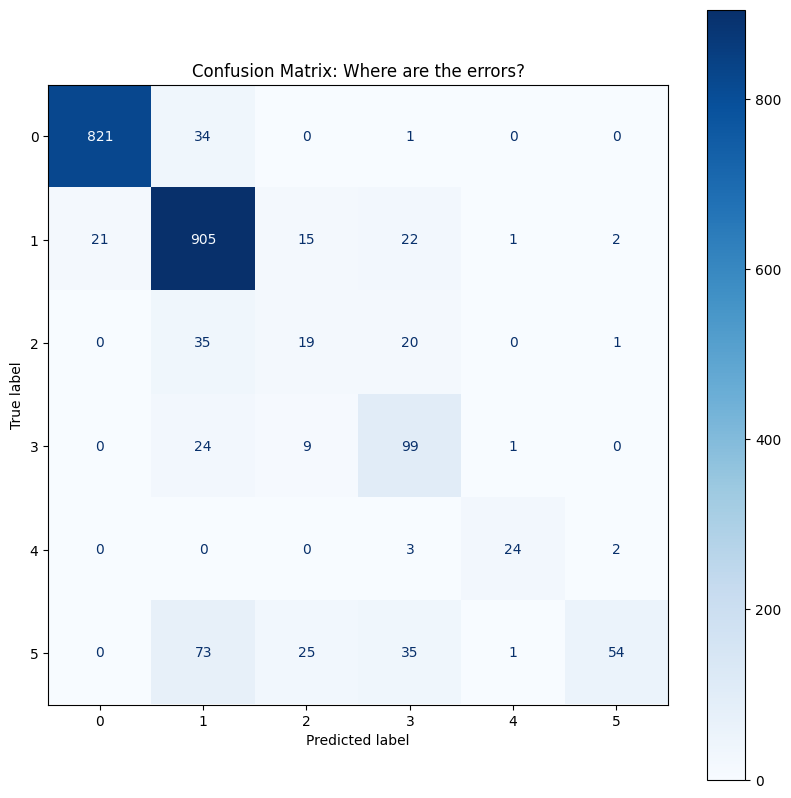


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9670 (Support: 856.0)
Label 1: F1 = 0.8886 (Support: 966.0)
Label 2: F1 = 0.2657 (Support: 75.0)
Label 3: F1 = 0.6326 (Support: 133.0)
Label 4: F1 = 0.8571 (Support: 29.0)
Label 5: F1 = 0.4372 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.7109


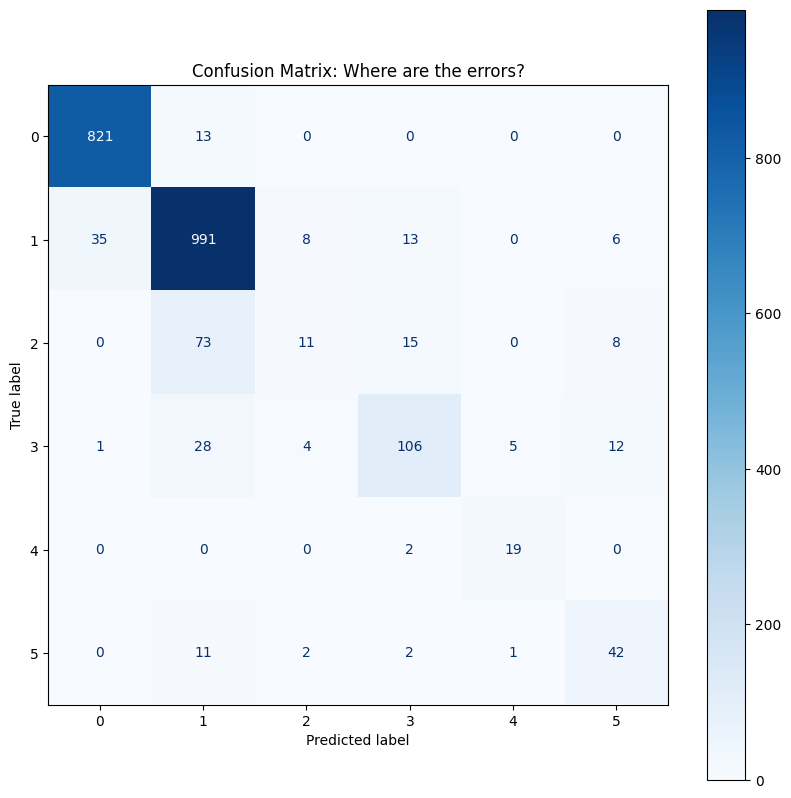


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9710 (Support: 834.0)
Label 1: F1 = 0.9138 (Support: 1053.0)
Label 2: F1 = 0.1667 (Support: 107.0)
Label 3: F1 = 0.7211 (Support: 156.0)
Label 4: F1 = 0.8261 (Support: 21.0)
Label 5: F1 = 0.6667 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7617


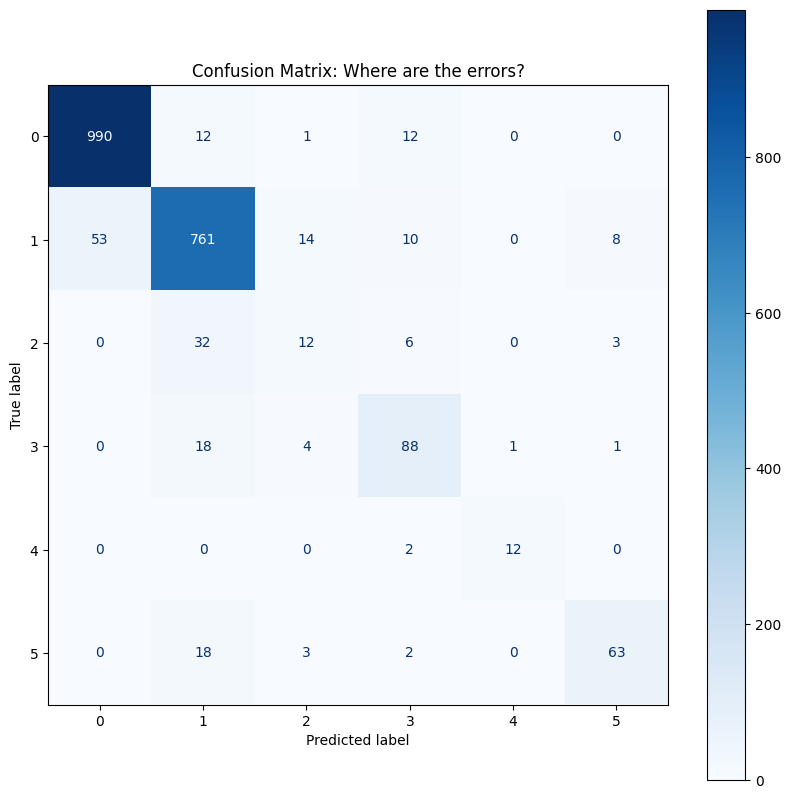


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9621 (Support: 1015.0)
Label 1: F1 = 0.9022 (Support: 846.0)
Label 2: F1 = 0.2759 (Support: 53.0)
Label 3: F1 = 0.7586 (Support: 112.0)
Label 4: F1 = 0.8889 (Support: 14.0)
Label 5: F1 = 0.7826 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7724


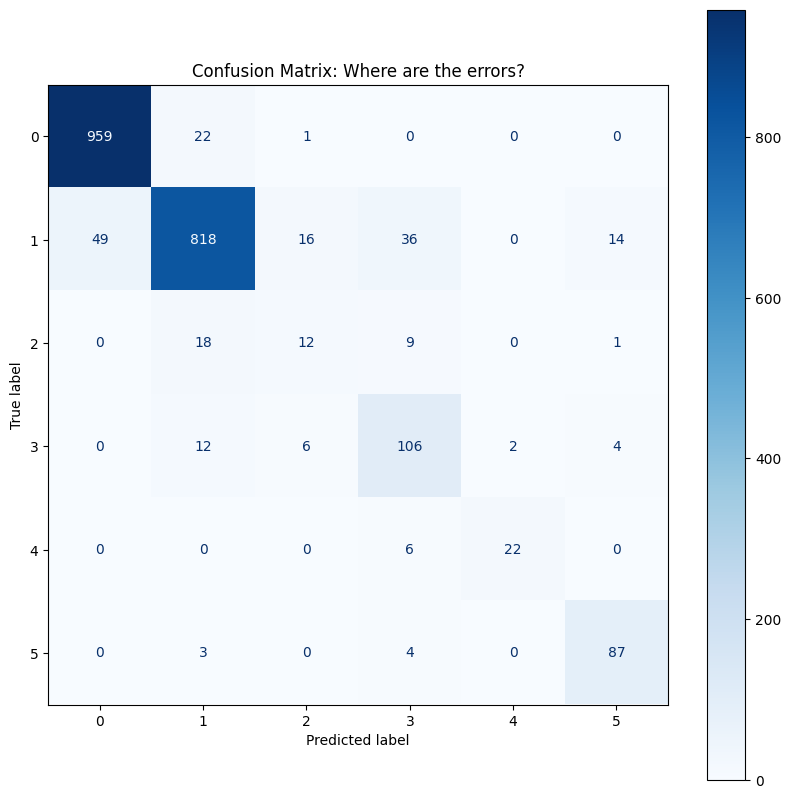


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9638 (Support: 982.0)
Label 1: F1 = 0.9059 (Support: 933.0)
Label 2: F1 = 0.3200 (Support: 40.0)
Label 3: F1 = 0.7285 (Support: 130.0)
Label 4: F1 = 0.8462 (Support: 28.0)
Label 5: F1 = 0.8700 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.7185


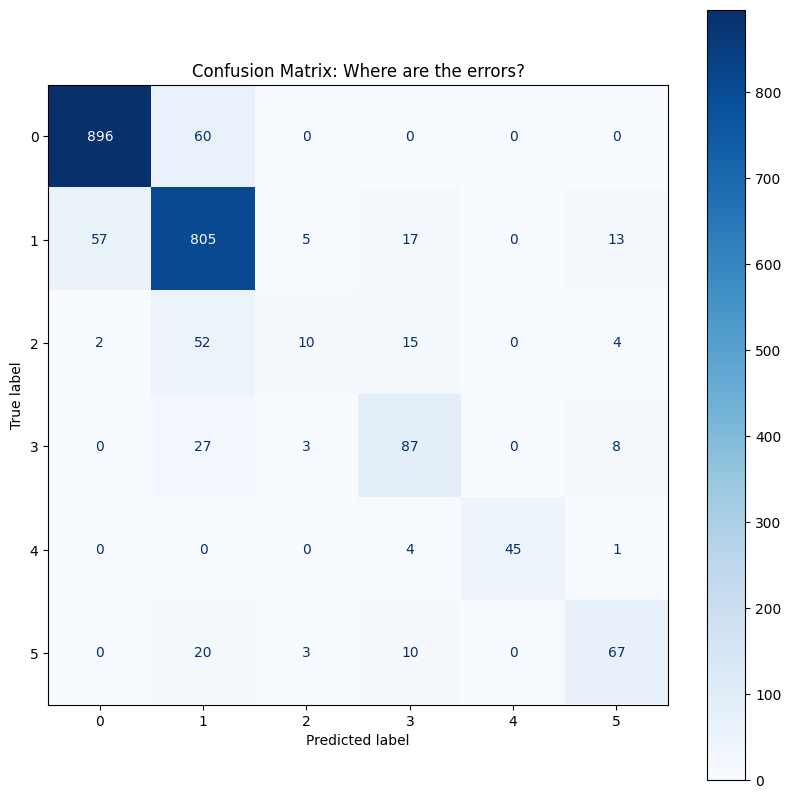


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9377 (Support: 956.0)
Label 1: F1 = 0.8651 (Support: 897.0)
Label 2: F1 = 0.1923 (Support: 83.0)
Label 3: F1 = 0.6744 (Support: 125.0)
Label 4: F1 = 0.9474 (Support: 50.0)
Label 5: F1 = 0.6943 (Support: 100.0)
(2054700, 9)
Training Final Model on 100% of Data...
Predicting Test Probabilities...
submission.csv successfully generated.


In [23]:
# Addition of Window Feature, Signal Granularity Feature to baseline 3
def build_file_features(df, window_size=30, step_size=15):
    df = df.copy()
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        series = df[col]
        feats[f"{col}_mean"] = series.mean()
        feats[f"{col}_std"] = series.std()
        feats[f"{col}_min"] = series.min()
        feats[f"{col}_max"] = series.max()
        feats[f"{col}_median"] = series.median()
        feats[f"{col}_q25"] = series.quantile(0.25)
        feats[f"{col}_q75"] = series.quantile(0.75)
        feats[f"{col}_mean_trends"] = series.diff().abs().mean()
        feats[f"range_{col}"] = series.max() - series.min()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0

    for col in ["mean_x", "mean_y", "mean_z"]:
        diff_series = df[col].diff().dropna() - df[col].diff().dropna().mean()
        zcr = np.nonzero(np.diff(np.sign(diff_series)))[0].size / (len(df) + 1e-6)
        feats[f"{col}_jerk_zcr"] = zcr
        
    feats["gravity_dominance_x"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_y"] = feats["mean_y_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_z"] = feats["mean_z_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["x_to_mag_ratio"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)

    sub_means = []
    sub_stds = []
    sub_ranges = []
    
    for start in range(0, len(df) - window_size + 1, step_size):
        w_df = df.iloc[start : start + window_size]
        sub_means.append(w_df["mag_mean"].mean())
        sub_stds.append(w_df["mag_mean"].std())
        sub_ranges.append(w_df["mag_mean"].max() - w_df["mag_mean"].min())
        
    if sub_means:
        feats["sub_window_mag_std_max"] = np.max(sub_stds)
        feats["sub_window_mag_std_min"] = np.min(sub_stds)
        feats["sub_window_mag_range_max"] = np.max(sub_ranges)
        feats["variance_between_sub_windows"] = np.var(sub_means)
        
    # FRACTIONAL INTENSITY
    global_mag_median = feats["mag_mean_median"]
    feats["fraction_above_median"] = (df["mag_mean"] > global_mag_median).sum() / len(df)
    
    # High-intensity burst detection
    high_thresh = feats["mag_mean_mean"] + (2 * feats["mag_mean_std"])
    feats["fraction_high_intensity"] = (df["mag_mean"] > high_thresh).sum() / len(df)
    
    # ADDED SIGNAL REGULARITY
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        series = df[col]
        if len(series) > 5:
            feats[f"{col}_autocorr_1"] = series.autocorr(lag=1)
            feats[f"{col}_autocorr_2"] = series.autocorr(lag=2)
            feats[f"{col}_rolling_energy"] = series.diff().var()
        else:
            feats[f"{col}_autocorr_1"] = 0
            feats[f"{col}_autocorr_2"] = 0
            feats[f"{col}_rolling_energy"] = 0

    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    colsample_bytree=0.7,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)

    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")

test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):

    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):

        df = pd.read_csv(csv_file)

        df["source_file"] = os.path.basename(csv_file)

        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

print(test_rows.shape)
test_rows.head()

print("Training Final Model on 100% of Data...")
lgbm_model.fit(X, y)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

print("Predicting Test Probabilities...")
test_raw_probs = lgbm_model.predict_proba(X_test)
test_preds = np.argmax(test_raw_probs, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")


Fold 0: train=8773, val=2247
Validation Label Distribution:
{0: 856, 1: 966, 2: 75, 3: 133, 4: 29, 5: 188}
Fold 1 Macro F1: 0.6759


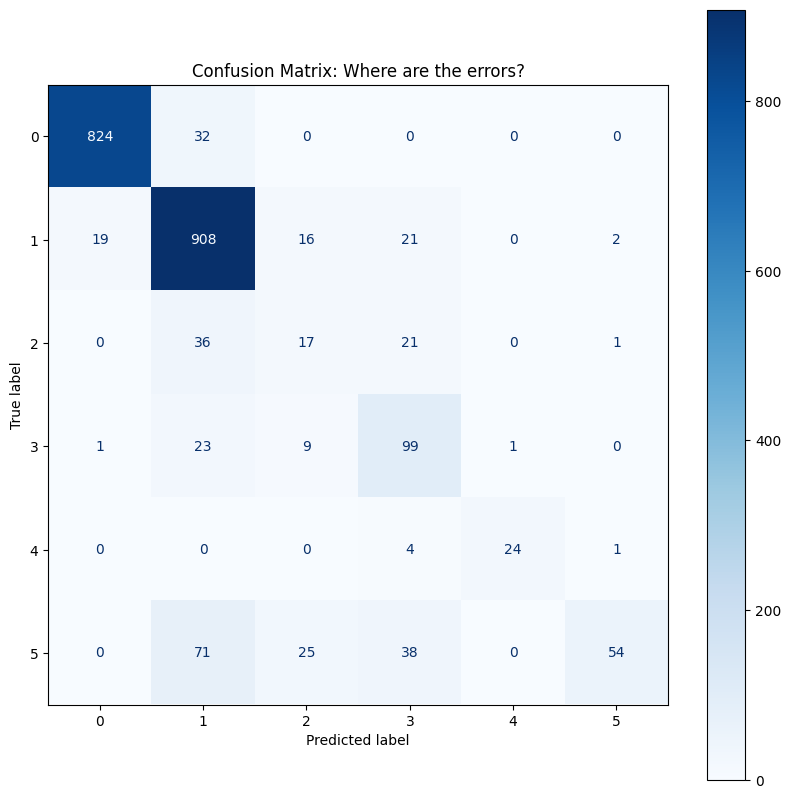


Per-Class F1 Scores for Fold 0:
Label 0: F1 = 0.9694 (Support: 856.0)
Label 1: F1 = 0.8919 (Support: 966.0)
Label 2: F1 = 0.2394 (Support: 75.0)
Label 3: F1 = 0.6266 (Support: 133.0)
Label 4: F1 = 0.8889 (Support: 29.0)
Label 5: F1 = 0.4390 (Support: 188.0)

Fold 1: train=8791, val=2229
Validation Label Distribution:
{0: 834, 1: 1053, 2: 107, 3: 156, 4: 21, 5: 58}
Fold 2 Macro F1: 0.7082


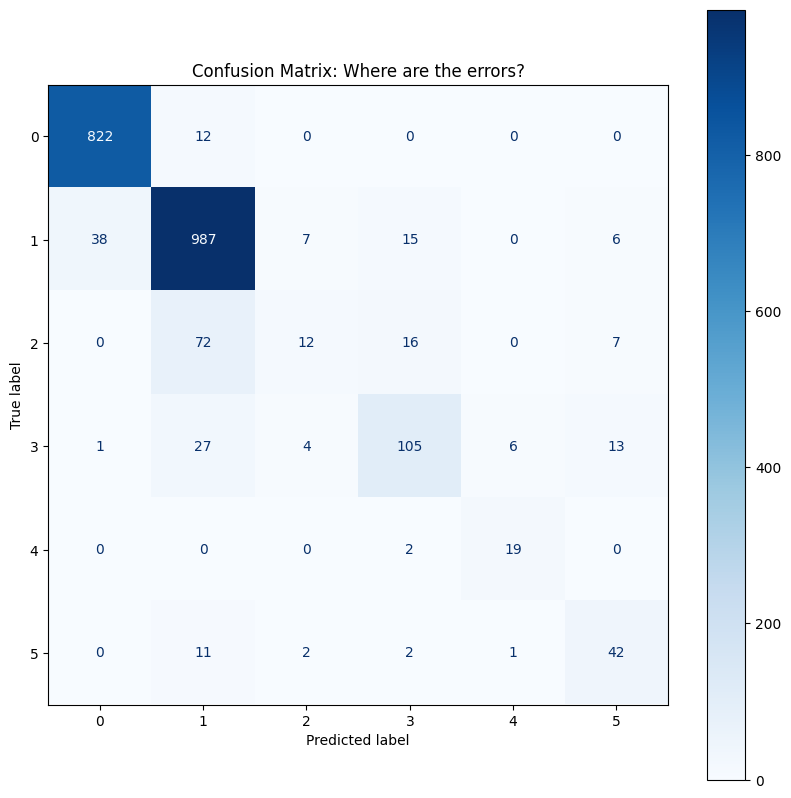


Per-Class F1 Scores for Fold 1:
Label 0: F1 = 0.9699 (Support: 834.0)
Label 1: F1 = 0.9130 (Support: 1053.0)
Label 2: F1 = 0.1818 (Support: 107.0)
Label 3: F1 = 0.7095 (Support: 156.0)
Label 4: F1 = 0.8085 (Support: 21.0)
Label 5: F1 = 0.6667 (Support: 58.0)

Fold 2: train=8894, val=2126
Validation Label Distribution:
{0: 1015, 1: 846, 2: 53, 3: 112, 4: 14, 5: 86}
Fold 3 Macro F1: 0.7555


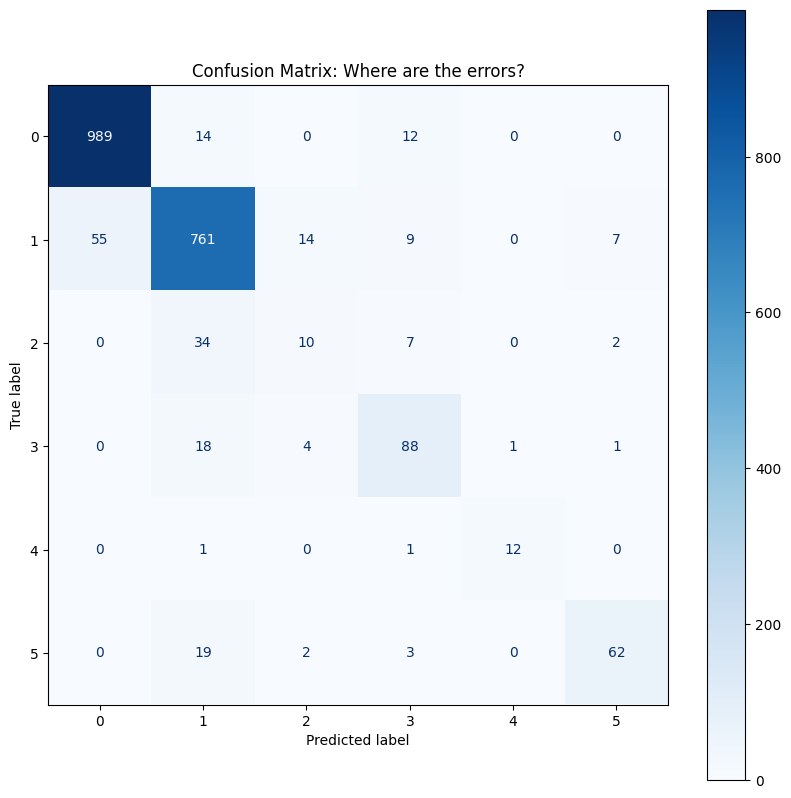


Per-Class F1 Scores for Fold 2:
Label 0: F1 = 0.9607 (Support: 1015.0)
Label 1: F1 = 0.8990 (Support: 846.0)
Label 2: F1 = 0.2410 (Support: 53.0)
Label 3: F1 = 0.7586 (Support: 112.0)
Label 4: F1 = 0.8889 (Support: 14.0)
Label 5: F1 = 0.7848 (Support: 86.0)

Fold 3: train=8813, val=2207
Validation Label Distribution:
{0: 982, 1: 933, 2: 40, 3: 130, 4: 28, 5: 94}
Fold 4 Macro F1: 0.7711


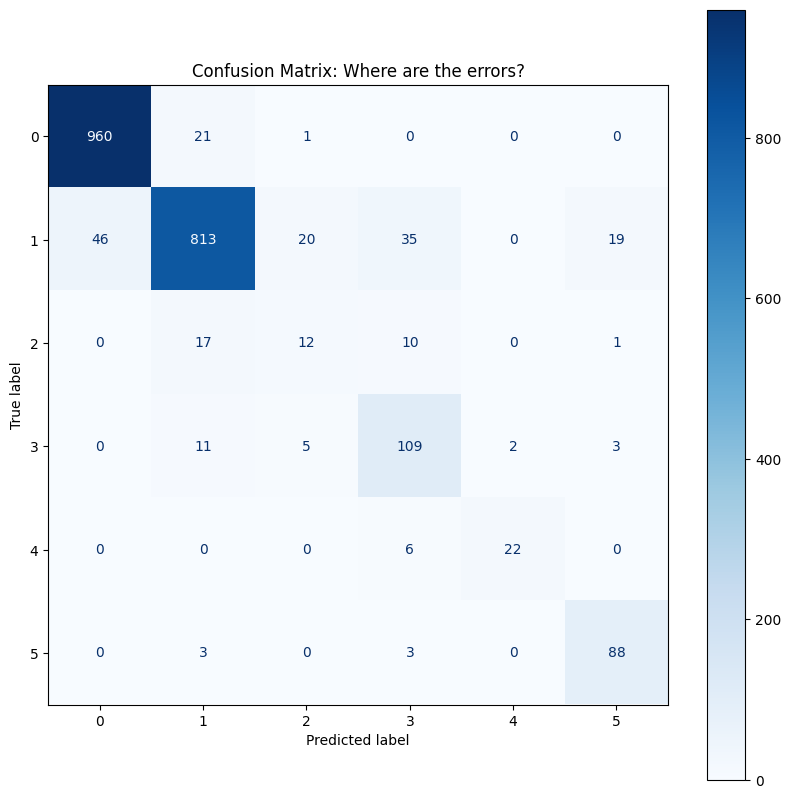


Per-Class F1 Scores for Fold 3:
Label 0: F1 = 0.9658 (Support: 982.0)
Label 1: F1 = 0.9043 (Support: 933.0)
Label 2: F1 = 0.3077 (Support: 40.0)
Label 3: F1 = 0.7440 (Support: 130.0)
Label 4: F1 = 0.8462 (Support: 28.0)
Label 5: F1 = 0.8585 (Support: 94.0)

Fold 4: train=8809, val=2211
Validation Label Distribution:
{0: 956, 1: 897, 2: 83, 3: 125, 4: 50, 5: 100}
Fold 5 Macro F1: 0.7132


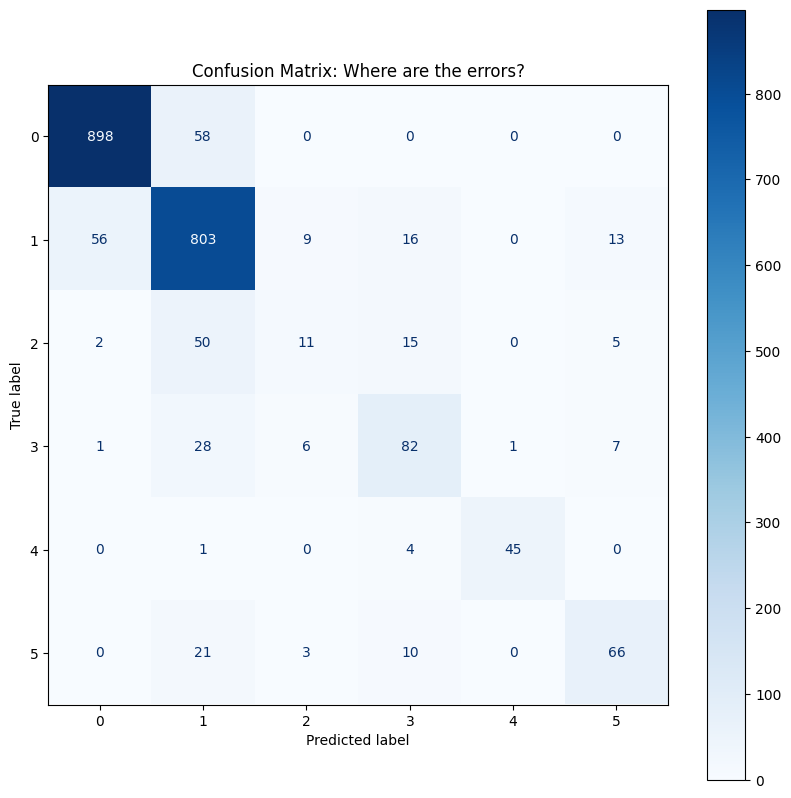


Per-Class F1 Scores for Fold 4:
Label 0: F1 = 0.9388 (Support: 956.0)
Label 1: F1 = 0.8644 (Support: 897.0)
Label 2: F1 = 0.1964 (Support: 83.0)
Label 3: F1 = 0.6508 (Support: 125.0)
Label 4: F1 = 0.9375 (Support: 50.0)
Label 5: F1 = 0.6911 (Support: 100.0)
(2054700, 9)
Training Final Model on 100% of Data...
Predicting Test Probabilities...
submission.csv successfully generated.


In [22]:
# Addition of Window Feature, Signal Granularity Feature to baseline 3 without colsample_bytree
def build_file_features(df, window_size=30, step_size=15):
    df = df.copy()
    feats = {}

    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        series = df[col]
        feats[f"{col}_mean"] = series.mean()
        feats[f"{col}_std"] = series.std()
        feats[f"{col}_min"] = series.min()
        feats[f"{col}_max"] = series.max()
        feats[f"{col}_median"] = series.median()
        feats[f"{col}_q25"] = series.quantile(0.25)
        feats[f"{col}_q75"] = series.quantile(0.75)
        feats[f"{col}_mean_trends"] = series.diff().abs().mean()
        feats[f"range_{col}"] = series.max() - series.min()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0

    for col in ["mean_x", "mean_y", "mean_z"]:
        diff_series = df[col].diff().dropna() - df[col].diff().dropna().mean()
        zcr = np.nonzero(np.diff(np.sign(diff_series)))[0].size / (len(df) + 1e-6)
        feats[f"{col}_jerk_zcr"] = zcr
        
    feats["gravity_dominance_x"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_y"] = feats["mean_y_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_z"] = feats["mean_z_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["x_to_mag_ratio"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)

    sub_means = []
    sub_stds = []
    sub_ranges = []
    
    for start in range(0, len(df) - window_size + 1, step_size):
        w_df = df.iloc[start : start + window_size]
        sub_means.append(w_df["mag_mean"].mean())
        sub_stds.append(w_df["mag_mean"].std())
        sub_ranges.append(w_df["mag_mean"].max() - w_df["mag_mean"].min())
        
    if sub_means:
        feats["sub_window_mag_std_max"] = np.max(sub_stds)
        feats["sub_window_mag_std_min"] = np.min(sub_stds)
        feats["sub_window_mag_range_max"] = np.max(sub_ranges)
        feats["variance_between_sub_windows"] = np.var(sub_means)
        
    # FRACTIONAL INTENSITY
    global_mag_median = feats["mag_mean_median"]
    feats["fraction_above_median"] = (df["mag_mean"] > global_mag_median).sum() / len(df)
    
    # High-intensity burst detection (e.g., fall detection or jump triggers)
    high_thresh = feats["mag_mean_mean"] + (2 * feats["mag_mean_std"])
    feats["fraction_high_intensity"] = (df["mag_mean"] > high_thresh).sum() / len(df)
    
    # ADDED SIGNAL REGULARITY
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        series = df[col]
        if len(series) > 5:
            feats[f"{col}_autocorr_1"] = series.autocorr(lag=1)
            feats[f"{col}_autocorr_2"] = series.autocorr(lag=2)
            feats[f"{col}_rolling_energy"] = series.diff().var()
        else:
            feats[f"{col}_autocorr_1"] = 0
            feats[f"{col}_autocorr_2"] = 0
            feats[f"{col}_rolling_energy"] = 0

    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]
groups = train_file_df["user"]

from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    val_counts = y_va.value_counts().reindex(range(6), fill_value=0)
    print(f"\nFold {fold}: train={len(tr_idx)}, val={len(va_idx)}")
    print(f"Validation Label Distribution:\n{val_counts.to_dict()}")
    
    if (val_counts == 0).any():
        print(f"CRITICAL WARNING: Fold {fold} is missing labels. Macro F1 will be distorted.")
    
    lgbm_model.fit(X_tr, y_tr)
    pred = lgbm_model.predict(X_va)
    
    score = f1_score(y_va, pred, average='macro')
    fold_scores.append(score)
    
    print(f"Fold {fold+1} Macro F1: {score:.4f}")
    cm = confusion_matrix(y_va, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap='Blues', ax=ax)
    plt.title("Confusion Matrix: Where are the errors?")
    plt.show()

    report = classification_report(y_va, pred, output_dict=True)
    print(f"\nPer-Class F1 Scores for Fold {fold}:")
    for label in range(6):
        f1 = report[str(label)]['f1-score']
        support = report[str(label)]['support']
        print(f"Label {label}: F1 = {f1:.4f} (Support: {support})")

test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):

    user = os.path.basename(user_folder)

    for csv_file in glob(os.path.join(user_folder, '*.csv')):

        df = pd.read_csv(csv_file)

        df["source_file"] = os.path.basename(csv_file)

        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

print(test_rows.shape)
test_rows.head()

print("Training Final Model on 100% of Data...")
lgbm_model.fit(X, y)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

print("Predicting Test Probabilities...")
test_raw_probs = lgbm_model.predict_proba(X_test)
test_preds = np.argmax(test_raw_probs, axis=1)

submission = pd.DataFrame({
    "Id": test_df["file_id"],
    "Label": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")

In [5]:
# Seed averaging with colsample_bytree set at 0.6
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

def build_file_features(df):
    feats = {}

    # magnitude features
    df["mag_mean"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2)
    df["mag_std"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2)
    df["denom"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2) + 1e-6
    df["pitch"] = np.arctan2(df["mean_x"], df["denom"])
    df["roll"] = np.arctan2(df["mean_y"], df["mean_z"] + 1e-6)

    all_cols = feature_cols + ["mag_mean", "mag_std", "denom", "pitch", "roll"]
    
    for col in all_cols:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"] = df[col].std()
        feats[f"{col}_min"] = df[col].min()
        feats[f"{col}_max"] = df[col].max()
        feats[f"{col}_median"] = df[col].median()
        feats[f"{col}_q25"] = df[col].quantile(0.25)
        feats[f"{col}_q75"] = df[col].quantile(0.75)
        feats[f"{col}_mean_trends"] = df[col].diff().abs().mean()
        feats[f"range_{col}"] = df[col].max() - df[col].min()

    feats["jerk_x_rms"] = np.sqrt(np.mean(df["mean_x"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_y_rms"] = np.sqrt(np.mean(df["mean_y"].diff().dropna()**2)) if len(df) > 1 else 0
    feats["jerk_z_rms"] = np.sqrt(np.mean(df["mean_z"].diff().dropna()**2)) if len(df) > 1 else 0
    
    for col in ["mean_x", "mean_y", "mean_z", "mag_mean"]:
        feats[f"{col}_ptp"] = df[col].max() - df[col].min()
        
    feats["corr_xy"] = df["mean_x"].corr(df["mean_y"]) if df["mean_x"].std() > 0 else 0
    feats["corr_xz"] = df["mean_x"].corr(df["mean_z"]) if df["mean_x"].std() > 0 else 0
    feats["corr_yz"] = df["mean_y"].corr(df["mean_z"]) if df["mean_y"].std() > 0 else 0

    for col in ["mean_x", "mean_y", "mean_z"]:
        diff_series = df[col].diff().dropna() - df[col].diff().dropna().mean()
        # Count how many times the signal passes zero line
        zcr = np.nonzero(np.diff(np.sign(diff_series)))[0].size / (len(df) + 1e-6)
        feats[f"{col}_jerk_zcr"] = zcr
        
    feats["gravity_dominance_x"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_y"] = feats["mean_y_mean"] / (feats["mag_mean_mean"] + 1e-6)
    feats["gravity_dominance_z"] = feats["mean_z_mean"] / (feats["mag_mean_mean"] + 1e-6)

    feats["x_to_mag_ratio"] = feats["mean_x_mean"] / (feats["mag_mean_mean"] + 1e-6)

    return feats

file_rows = []
for file_id, g in train_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    row["user"] = g["user"].iloc[0]
    row["label"] = g["label"].iloc[0]
    file_rows.append(row)

train_file_df = pd.DataFrame(file_rows)

X = train_file_df.drop(columns=["file_id", "user", "label"])
y = train_file_df["label"]

test_path = '/kaggle/input/datasets/dhammaruci/data-mining-assignment-3/test/test'
all_test_files = []

for user_folder in glob(os.path.join(test_path, '*')):
    user = os.path.basename(user_folder)
    for csv_file in glob(os.path.join(user_folder, '*.csv')):
        df = pd.read_csv(csv_file)
        df["source_file"] = os.path.basename(csv_file)
        all_test_files.append(df)

test_rows = pd.concat(all_test_files, ignore_index=True)

test_file_rows = []
for file_id, g in test_rows.groupby("file_id"):
    row = build_file_features(g)
    row["file_id"] = file_id
    test_file_rows.append(row)

test_df = pd.DataFrame(test_file_rows)
X_test = test_df.drop(columns=["file_id"])

full_data_test_probs = np.zeros((len(X_test), 6))
seeds = [42, 123, 456, 789, 999]

print("Training 5 Seed Models on 100% of Training Data...")

for seed in seeds:
    print(f"--> Training Model with Seed {seed}...")
    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=31,
        class_weight='balanced',   
        colsample_bytree=0.6,
        random_state=seed,         
        verbose=-1
    )
    
    model.fit(X, y)
    full_data_test_probs += model.predict_proba(X_test) / len(seeds)

print("100% Data Ensemble Complete.")

seed_test_preds = np.argmax(full_data_test_probs, axis=1)

submission_seed = pd.DataFrame({"Id": test_df["file_id"], "Label": seed_test_preds})
submission_seed.to_csv("submission_seed_averaging_06.csv", index=False)
print("submission_seed_averaging_06.csv generated.")

Training 5 Seed Models on 100% of Training Data...
--> Training Model with Seed 42...
--> Training Model with Seed 123...
--> Training Model with Seed 456...
--> Training Model with Seed 789...
--> Training Model with Seed 999...
100% Data Ensemble Complete.
submission_seed_averaging_06.csv generated.
